# Diurnal filtering

In [1316]:
ERA_v,MERRA_v=(0.5, 0.5)
ISMN=pd.read_csv(ISMN_sm[i],usecols={'date_time','soil_moisture','flag','anomaly','rm'},index_col='date_time',parse_dates=['date_time'])
ERA=pd.read_csv(ERA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
MERRA=pd.read_csv(MERRA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
ts_ISMN=pd.read_csv(ISMN_ts[i],usecols={'date_time','soil_temperature','flag','anomaly'},index_col='date_time',parse_dates=['date_time'])
ISMN2=pd.read_csv(ISMN_sm[i])

ISMN=ISMN[ISMN['flag']=='G']
ts_ISMN=ts_ISMN[ts_ISMN['flag']=='G']
ISMN=ISMN[['soil_moisture','anomaly','rm']]
ts_ISMN=ts_ISMN[['soil_temperature','anomaly']]

ISMN.rename(columns={'soil_moisture':'ISMN sm','anomaly':'ISMN sm ano','rm':'ISMN rm'},inplace=True)
ERA.rename(columns={'sm':'ERA sm','sm ano':'ERA sm ano','ts':'ERA ts','ts ano':'ERA ts ano'},inplace=True)
MERRA.rename(columns={'sm':'MERRA sm','sm ano':'MERRA sm ano','ts':'MERRA ts','ts ano':'MERRA ts ano'},inplace=True)
ts_ISMN.rename(columns={'soil_temperature':'ISMN ts','anomaly':'ISMN ts ano'},inplace=True)

merged = ISMN.merge(ERA, left_index=True, right_index=True, how='inner')
merged = merged.merge(MERRA, left_index=True, right_index=True, how='inner')
merged = merged.merge(ts_ISMN, left_index=True, right_index=True, how='inner')
merged = merged.dropna()

'Phase adjustment'
if len(merged) > 2200:
    fft_ISMN_ano=np.fft.fft(merged['ISMN sm ano'])
    ps_ISMN_ano=np.abs(fft_ISMN_ano)
    freq_ISMN_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ISMN_ano))
    
    fft_ERA_ano=np.fft.fft(merged['ERA sm ano'])
    ps_ERA_ano=np.abs(fft_ERA_ano)
    freq_ERA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ERA_ano))
    
    fft_MERRA_ano=np.fft.fft(merged['MERRA sm ano'])
    ps_MERRA_ano=np.abs(fft_MERRA_ano)
    freq_MERRA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_MERRA_ano))
    
    freq_24=int(len(freq_ISMN_ano)/24)
    freq_36=int(len(freq_ISMN_ano)/36)
    freq_12=int(len(freq_ISMN_ano)/12)
    
    df_ano=pd.DataFrame()
    df_ano['fft_ISMN_r']=fft_ISMN_ano.real
    df_ano['fft_ERA_r']=fft_ERA_ano.real
    df_ano['fft_MERRA_r']=fft_MERRA_ano.real
    df_ano['fft_m_r']=((ERA_v*df_ano['fft_ERA_r'])+(MERRA_v*df_ano['fft_MERRA_r']))
    df_ano['fft_ISMN_i']=fft_ISMN_ano.imag
    df_ano['fft_ERA_i']=fft_ERA_ano.imag
    df_ano['fft_MERRA_i']=fft_MERRA_ano.imag
    df_ano['fft_m_i']=((ERA_v*df_ano['fft_ERA_i'])+(MERRA_v*df_ano['fft_MERRA_i']))
    df_ano['ps_ISMN']=ps_ISMN_ano
    df_ano['ps_ERA']=ps_ERA_ano
    df_ano['ps_MERRA']=ps_MERRA_ano
    df_ano['ps_m']=((ERA_v*df_ano['ps_ERA'])+(MERRA_v*df_ano['ps_MERRA']))
    
    mv_ano=df_ano.rolling(window=24,center=True).mean()
    
    sf_ano_E=mv_ano['ps_ISMN']/mv_ano['ps_ERA']
    sf_ano_M=mv_ano['ps_ISMN']/mv_ano['ps_MERRA']
    sf_ano_all=mv_ano['ps_ISMN']/mv_ano['ps_m']
    
    fft_ano_r_E=sf_ano_E*df_ano['fft_ERA_r']
    fft_ano_i_E=sf_ano_E*df_ano['fft_ERA_i']
    fft_ano_r_M=sf_ano_M*df_ano['fft_MERRA_r']
    fft_ano_i_M=sf_ano_M*df_ano['fft_MERRA_i']
    fft_ano_r_all=sf_ano_all*df_ano['fft_m_r']
    fft_ano_i_all=sf_ano_all*df_ano['fft_m_i']
    
    fft_ano_resc_E=fft_ano_r_E+fft_ano_i_E*1j
    fft_ano_resc_M=fft_ano_r_M+fft_ano_i_M*1j
    fft_ano_resc_all=fft_ano_r_all+fft_ano_i_all*1j
    
    fft_ISMN_adj_ano_E=fft_ISMN_ano.copy()
    fft_ISMN_adj_ano_M=fft_ISMN_ano.copy()
    fft_ISMN_adj_ano_all=fft_ISMN_ano.copy()
    
    fft_ISMN_adj_ano_E[freq_36:freq_12]=fft_ano_resc_E[freq_36:freq_12]
    fft_ISMN_adj_ano_E[-freq_12:-freq_36]=fft_ano_resc_E[-freq_12:-freq_36]
    fft_ISMN_adj_ano_M[freq_36:freq_12]=fft_ano_resc_M[freq_36:freq_12]
    fft_ISMN_adj_ano_M[-freq_12:-freq_36]=fft_ano_resc_M[-freq_12:-freq_36]
    fft_ISMN_adj_ano_all[freq_36:freq_12]=fft_ano_resc_all[freq_36:freq_12]
    fft_ISMN_adj_ano_all[-freq_12:-freq_36]=fft_ano_resc_all[-freq_12:-freq_36]
    
    ps_ano_adj_E=np.abs(fft_ISMN_adj_ano_E)
    ps_ano_adj_M=np.abs(fft_ISMN_adj_ano_M)
    ps_ano_adj_all=np.abs(fft_ISMN_adj_ano_all)
    
    ifft_ISMN_ano_E=np.fft.ifft(fft_ISMN_adj_ano_E)
    ifft_ISMN_ano_real_E=ifft_ISMN_ano_E.real
    ifft_ISMN_ano_M=np.fft.ifft(fft_ISMN_adj_ano_M)
    ifft_ISMN_ano_real_M=ifft_ISMN_ano_M.real
    ifft_ISMN_ano_all=np.fft.ifft(fft_ISMN_adj_ano_all)
    ifft_ISMN_ano_real_all=ifft_ISMN_ano_all.real
    
    merged['ano_adj_E']=ifft_ISMN_ano_real_E
    merged['ano_adj_M']=ifft_ISMN_ano_real_M
    merged['ano_adj_all']=ifft_ISMN_ano_real_all
    
    hourly=merged.groupby(merged.index.hour).mean()
    
'nighttime mean correction'
    night=hourly.loc[list(range(7))+list(range(20,24))]

    merged_copy=merged.copy()
    merged_copy['date']=merged_copy.index.date
    merged_copy['hour']=merged_copy.index.hour
    merged_copy=merged_copy.groupby('date', group_keys=False).apply(adjust_night)
    filter_date=merged_copy.loc[merged_copy['night_adj'] < 0, 'date'].unique()
    merged_copy['night_adj2']=merged_copy['night_adj']

    for j in filter_date:
        filter_start=merged_copy[merged_copy['date'] == j][['night_adj']].copy()
        night_mean=np.mean(filter_start['night_adj'])
        filter_start['step1']=filter_start['night_adj']-night_mean
        filter_min=np.min(filter_start['step1'])
        if night_mean > 0 : 
            if abs(filter_min) < 1:
                filter_start['step2']=filter_start['step1']*abs(filter_min)
                filter_start['step3']=filter_start['step2']+night_mean
                merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
            elif abs(filter_min) > 1:
                filter_start['step2']=filter_start['step1']/abs(filter_min)
                filter_start['step3']=filter_start['step2']+night_mean
                merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
        elif night_mean < 0 :
            if abs(filter_min) < 1:
                filter_start['step2']=filter_start['step1']*abs(filter_min)
                filter_start['step3']=filter_start['step2']+abs(np.min(filter_start['step2']))
                merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
            elif abs(filter_min) > 1:
                filter_start['step2']=filter_start['step1']/abs(filter_min)
                filter_start['step3']=filter_start['step2']+abs(np.min(filter_start['step2']))
                merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']

    merged_copy=merged_copy.drop(columns=['date','hour'])
    hourly=merged_copy.groupby(merged_copy.index.hour).mean()            

# plot

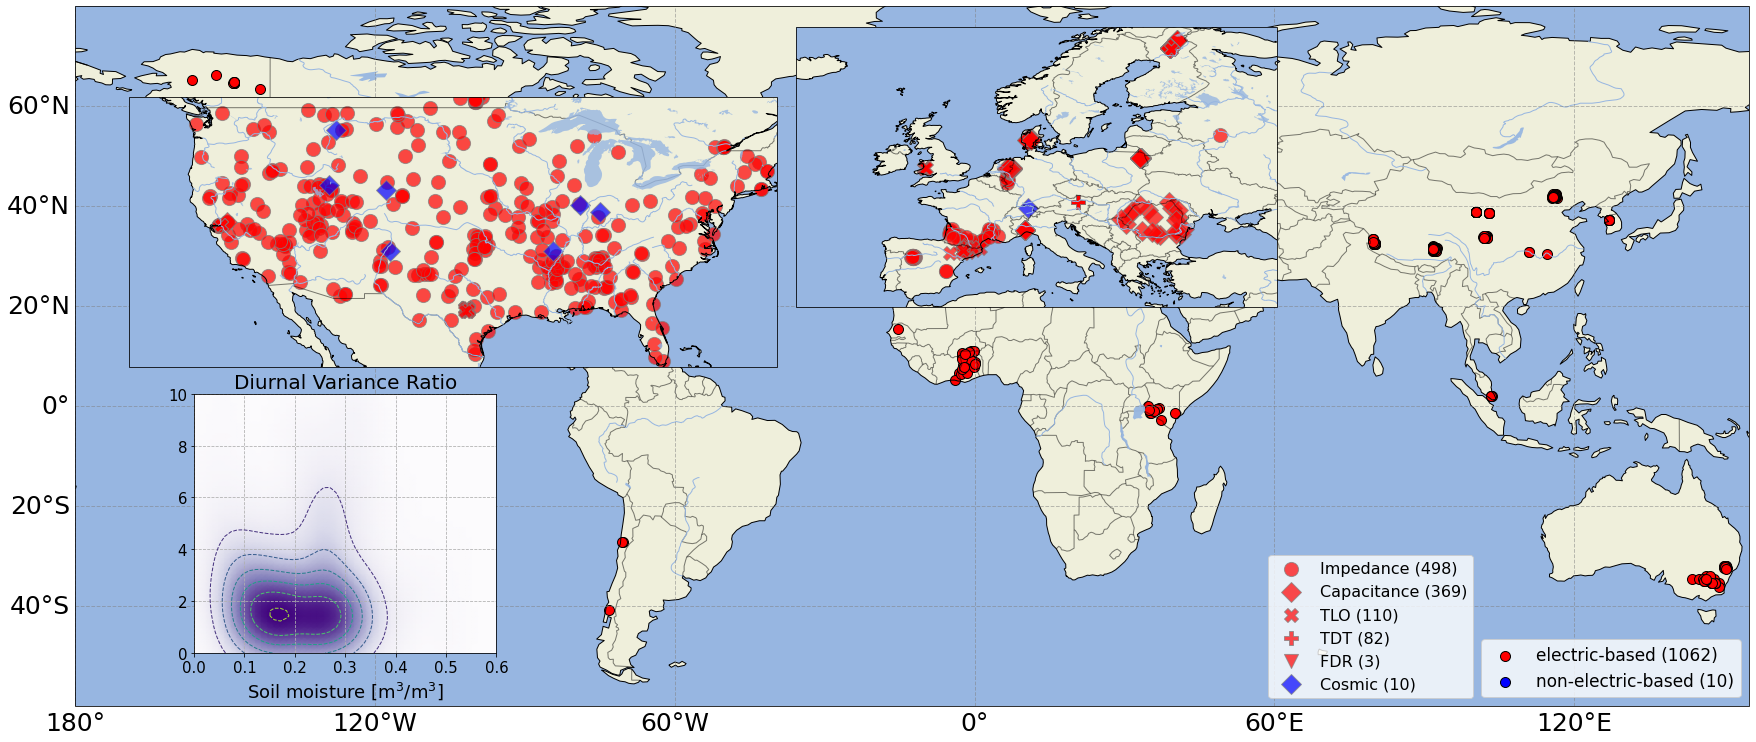

In [1260]:
# Fig.1
fig = plt.figure(figsize=(30, 30))
fig.set_facecolor('white')

# Main map
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_extent([-180, 155, -60, 80], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=.5)
ax.add_feature(cfeature.LAKES, alpha=0.95)
ax.add_feature(cfeature.RIVERS)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 25}
gl.ylabel_style = {'size': 25}
scatter_elec = ax.scatter(elec['lon'], elec['lat'], c='r', transform=ccrs.PlateCarree(), s=100, alpha=1, edgecolor='k', label=f'electric-based ({len(elec)})')
scatter_n_elec = ax.scatter(n_elec['lon'], n_elec['lat'], c='b', transform=ccrs.PlateCarree(), s=100, alpha=1, edgecolor='k', label=f'non-electric-based ({len(n_elec)})')

# CONUS
ax_inset = fig.add_axes([0.15, 0.41, 0.3, 0.3], projection=ccrs.PlateCarree())
ax_inset.set_extent([-130, -70, 25, 50], crs=ccrs.PlateCarree())
ax_inset.coastlines()
ax_inset.add_feature(cfeature.LAND)
ax_inset.add_feature(cfeature.OCEAN)
ax_inset.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset.add_feature(cfeature.RIVERS)

scatter_Imp = ax_inset.scatter(Impedance['lon'], Impedance['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='o', edgecolor='gray', label='Impedance')
scatter_FDR = ax_inset.scatter(FDR['lon'], FDR['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='v', edgecolor='gray', label='FDR')
scatter_TDT = ax_inset.scatter(TDT['lon'], TDT['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='P', edgecolor='gray', label='TDT')
scatter_Cap = ax_inset.scatter(Capacitance['lon'], Capacitance['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='D', edgecolor='gray', label='Capacitance')
scatter_TLO = ax_inset.scatter(TLO['lon'], TLO['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='X', edgecolor='gray', label='TLO')
scatter_Cos = ax_inset.scatter(Cosmic['lon'], Cosmic['lat'], c='b', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='D', edgecolor='gray', label='Cosmic-ray')

handles_ax, labels_ax = ax.get_legend_handles_labels()
handles_inset = [scatter_Imp, scatter_Cap, scatter_TLO, scatter_TDT, scatter_FDR, scatter_Cos]
labels_inset = [f'Impedance ({len_Impedance})', f'Capacitance ({len_Capacitance})', f'TLO ({len_TLO})', f'TDT ({len_TDT})', f'FDR ({len_FDR})', f'Cosmic ({len_Cosmic})']

legend_ax = ax.legend(handles_ax, labels_ax, loc='lower right',fontsize=17,bbox_to_anchor=(1., .0))

legend_inset = ax.legend(handles_inset, labels_inset, loc='lower right', fontsize=16,bbox_to_anchor=(.84, .0))
ax.add_artist(legend_ax)

# EU
ax_inset2 = fig.add_axes([0.455, 0.525, 0.23, 0.13], projection=ccrs.PlateCarree())
ax_inset2.set_extent([-20, 40, 35, 70], crs=ccrs.PlateCarree()) 

ax_inset2.coastlines()
ax_inset2.add_feature(cfeature.LAND)
ax_inset2.add_feature(cfeature.OCEAN)
ax_inset2.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset2.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset2.add_feature(cfeature.RIVERS)

ax_inset2.scatter(Impedance['lon'], Impedance['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='o', edgecolor='gray', label='Impedance')
ax_inset2.scatter(FDR['lon'], FDR['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='v', edgecolor='gray', label='FDR')
ax_inset2.scatter(TDT['lon'], TDT['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='P', edgecolor='gray', label='TDT')
ax_inset2.scatter(Capacitance['lon'], Capacitance['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='D', edgecolor='gray', label='Capacitance')
ax_inset2.scatter(TLO['lon'], TLO['lat'], c='r', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='X', edgecolor='gray', label='TLO')
ax_inset2.scatter(Cosmic['lon'], Cosmic['lat'], c='b', transform=ccrs.PlateCarree(), s=200, alpha=.7, marker='D', edgecolor='gray', label='Cosmic-ray')

# Ratio plot
ax_ratio = fig.add_axes([0.18, 0.365, 0.14, 0.12]) 
data = np.column_stack((sm_m, var_f))
nbins = 50
xmin, xmax, ymin, ymax = 0, 0.6, 0, 10
k = stats.gaussian_kde(data.T)
xi, yi = np.mgrid[xmin:xmax:nbins*1j, ymin:ymax:nbins*1j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))
ax_ratio.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='gouraud', cmap='Purples')
ax_ratio.contour(xi, yi, zi.reshape(xi.shape), linewidths=1, linestyles='dashed', cmap='viridis')
ax_ratio.set_xlabel('Soil moisture [m$^3$/m$^3$]', fontsize=18)
ax_ratio.set_xlim(xmin, xmax)
ax_ratio.set_ylim(ymin, ymax)
ax_ratio.tick_params(axis='both', labelsize=15)
ax_ratio.grid(True, linestyle='--')
ax_ratio.set_title('Diurnal Variance Ratio', fontsize=20)

plt.show()

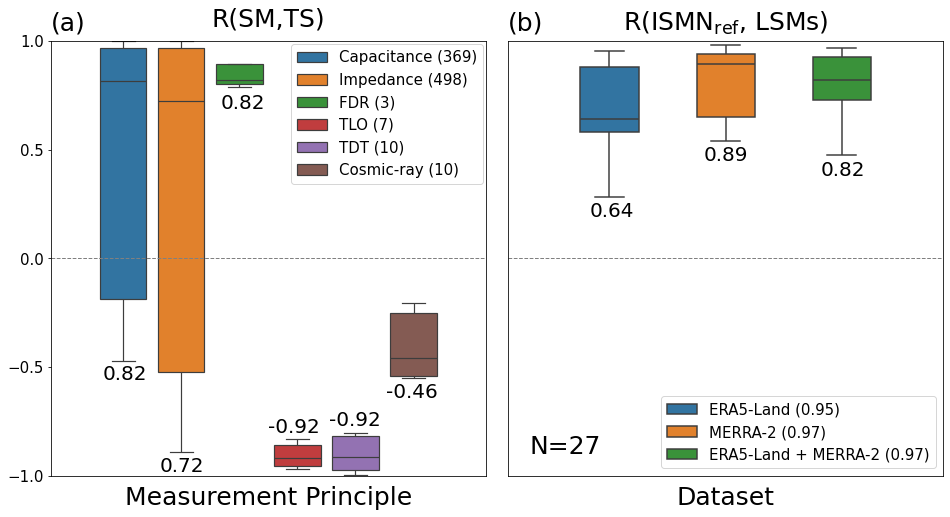

In [1263]:
# Fig.2
fig, axs = plt.subplots(1, 2, figsize=(16, 8),gridspec_kw={'wspace': 0.05})
fig.set_facecolor('white')

'(a)ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
sns.boxplot(x='principle',y='[-]',hue='sensor',data=R_concat,whis=0.25,gap=0.2,linewidth=1.2,showfliers=False, ax=axs[0])
axs[0].set_title('R(SM,TS)',fontsize=25,pad=15)
axs[0].set_xlabel('Measurement Principle', fontsize=25,labelpad=10)
axs[0].set_ylim(-1.,1.)
# axs[0].axhline(-0.41,c='r',linestyle='--',linewidth=1)
axs[0].axhline(0.0,c='gray',linestyle='--',linewidth=1)
axs[0].set_xticks([])
axs[0].set_yticks([-1.0,-0.5,0,0.5,1])
axs[0].tick_params(axis='y', labelsize=15)
axs[0].yaxis.label.set_visible(False)

handles_ax, labels_ax = axs[0].get_legend_handles_labels()
labels_inset=[f'Capacitance ({len(Cap_R)})',f'Impedance ({len(Imp_R)})', f'FDR ({len(FDR_R)})', f'TLO ({len(TLO_R)})',  f'TDT ({len(TDT_R)})', f'Cosmic-ray ({len(Cos_R)})']
legend_ax = axs[0].legend(handles_ax, labels_inset, bbox_to_anchor=(1.01,1.01), fontsize=15)

axs[0].text(-.5,1.05,'(a)',fontsize=25)
'(b)ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
sns.boxplot(x='Dataset', y='R(ISMN,dataset)', hue='data', data=concat_R_ano, linewidth=1.5, gap=0.5, whis=1.5, showfliers=False,ax=axs[1])
axs[1].set_title(r'R(ISMN$_{\text{ref}}$, LSMs)',fontsize=25,pad=10)
axs[1].set_xlabel('Dataset',fontsize=25, labelpad=10)
axs[1].set_ylim(-1.,1.)
# axs[1].axhline(0.41, linestyle='--', c='r', linewidth=1)
axs[1].axhline(0.0,c='gray',linestyle='--',linewidth=1)
axs[1].set_xticks([])
axs[1].set_yticks([-1.0,-0.5,0,0.5,1])
axs[1].tick_params(axis='y', labelsize=15)
axs[1].text(-.5,1.05,'(b)',fontsize=25)
axs[1].yaxis.label.set_visible(False)
axs[1].yaxis.set_visible(False)
# axs[1].set_ylim(0,1)


handles, labels = axs[1].get_legend_handles_labels()
new_labels = [f"{label} ({med})" for label, med in zip(labels, median2)]
axs[1].legend(handles, new_labels, fontsize=15, loc='lower right')# bbox_to_anchor=(1.02, 1))
axs[1].text(-.45,-.9,'N=27',fontsize=25)
axs[1].text(-0.313,0.19,median[0],fontsize=20)
axs[1].text(-0.05,0.45,median[1],fontsize=20)
axs[1].text(0.217,0.38,median[2],fontsize=20)

axs[0].text(-.38,-.56,Cap_m,fontsize=20)
axs[0].text(-.25,-.98,Imp_m,fontsize=20)
axs[0].text(-.11,.69,FDR_m,fontsize=20)
axs[0].text(0.,-.8,TLO_m,fontsize=20)
axs[0].text(.14,-.77,TDT_m,fontsize=20)
axs[0].text(.27,-.64,Cos_m,fontsize=20)
plt.show()

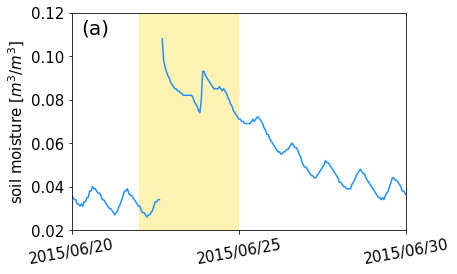

In [330]:
# Fig. 3a
fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')

plt.plot(ISMN_sm_ori.index,ISMN_sm_ori['soil_moisture'],c='dodgerblue')

P_idx=ISMN_sm_ori.index[~ISMN_sm_ori.index.isin(ISMN_sm_premove.dropna().index)]

plt.axvspan(P_idx[0], P_idx[-1], color='gold', alpha=0.3, label='Precipitation Period')
plt.ylabel('soil moisture [$m^3$/$m^3$]',fontsize=15)
ax = plt.gca()  
ax.set_xticks(xticks)
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
ax.set_xlim([xticks[0],xticks[-1]])
ax.set_ylim(0.02,0.12)
ax.text(0.03, 0.9, '(a)', fontsize=20, transform=ax.transAxes)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

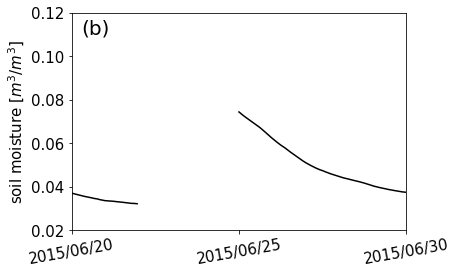

In [332]:
# Fig. 3b
fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')

plt.plot(ISMN_sm_premove.index,ISMN_sm_premove['running mean'],c='k',linestyle='-')
plt.ylabel('soil moisture [$m^3$/$m^3$]',fontsize=15)
ax = plt.gca()  
ax.set_xticks(xticks)
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
ax.set_xlim([xticks[0],xticks[-1]])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_ylim(0.02,0.12)
ax.text(0.03, 0.9, '(b)', fontsize=20, transform=ax.transAxes)
plt.show()

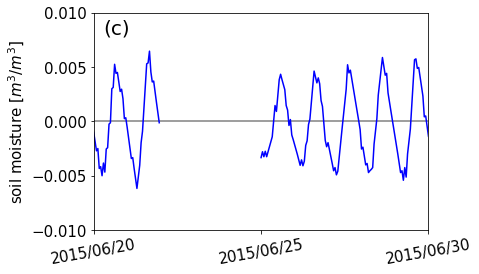

In [334]:
# Fig. 3c
fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')

plt.axhline(0, linewidth=1.5, c='gray')
plt.plot(ISMN_sm_premove.index,ISMN_sm_premove['anomaly'],c='b')
plt.ylabel('soil moisture [$m^3$/$m^3$]',fontsize=15)
ax = plt.gca()  
ax.set_xticks(xticks)
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
ax.set_xlim([xticks[0],xticks[-1]])
plt.xticks(fontsize=15)
plt.yticks([-0.01,-0.005,0,0.005,0.01],fontsize=15)
plt.ylim(-0.01,0.01)
ax.text(0.03, 0.9, '(c)', fontsize=20, transform=ax.transAxes)
plt.show()

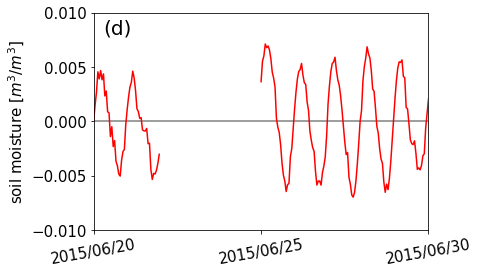

In [335]:
# Fig. 3d
fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')

plt.axhline(0, linewidth=1.5, c='gray')
plt.plot(merged.index,merged['adj_all'],c='r')
plt.ylabel('soil moisture [$m^3$/$m^3$]',fontsize=15)
ax = plt.gca()  
ax.set_xticks(xticks)
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
plt.xticks(fontsize=15)
ax.set_xlim([xticks[0],xticks[-1]])
plt.yticks([-0.01,-0.005,0,0.005,0.01],fontsize=15)
plt.ylim(-0.01,0.01)
ax.text(0.03, 0.9, '(d)', fontsize=20, transform=ax.transAxes)
plt.show()

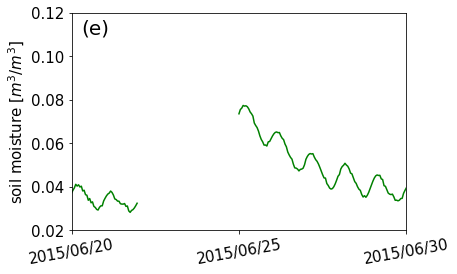

In [336]:
# Fig. 3e
fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')

plt.plot(merged.index,merged['adj_all']+(merged['ISMN sm']-merged['ISMN sm ano']),c='g')
plt.ylabel('soil moisture [$m^3$/$m^3$]',fontsize=15)
ax = plt.gca()  
ax.set_xticks(xticks)
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y/%m/%d'))
ax.set_xlim([xticks[0],xticks[-1]])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.set_ylim(0.02,0.12)
ax.text(0.03, 0.9, '(e)', fontsize=20, transform=ax.transAxes)
plt.show()

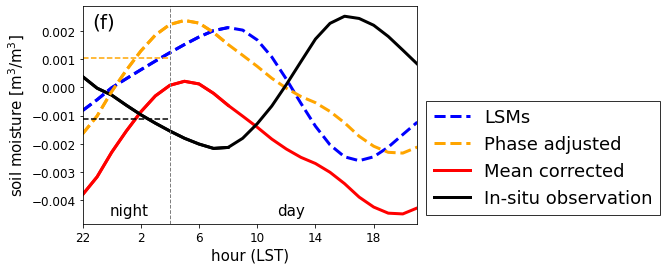

In [81]:
# Fig. 3f
fig = plt.figure(figsize=(6,4))
fig.set_facecolor('white')
plt.plot(x,hourly_reindex['LSMs'],label='LSMs',c='b',linewidth=3,linestyle='--')
plt.plot(x,hourly_reindex['adj_all'],label='Phase adjusted',c='orange',linewidth=3,linestyle='--')
plt.plot(x,hourly_reindex['night_adj'],label='Mean corrected',c='r',linewidth=3)
plt.plot(x,hourly_reindex['ISMN sm ano'],label='In-situ observation',c='k',linewidth=3)

plt.plot(x[:11],hourly_reindex['LSMs'][:11],c='b',linewidth=3,linestyle='--')
plt.plot(x[:11],hourly_reindex['night_adj'][:11],c='r',linewidth=3)
plt.plot(x[:11],hourly_reindex['ISMN sm ano'][:11],c='k',linewidth=3)
plt.plot(x[:11],hourly_reindex['adj_all'][:11],c='orange',linewidth=3,linestyle='--')

ISMN_mean_n = night['ISMN sm ano'].mean()
adj_mean_n = night['adj_all'].mean()
plt.axvline(x=6,linestyle='--',c='gray',linewidth=1.)
plt.plot([0, 6], [ISMN_mean_n, ISMN_mean_n], linestyle='--', c='k') 
plt.plot([0, 6], [adj_mean_n, adj_mean_n], linestyle='--', c='orange') 

plt.ylabel('soil moisture [m$^3$/m$^3$]',fontsize=15)
plt.xlabel('hour (LST)',fontsize=15)
plt.xticks(ticks=x[::4], labels=xtick_labels[::4], fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0,23)

ax = plt.gca()  
ax.text(0.03, 0.9, '(f)', fontsize=20, transform=ax.transAxes)
ax.text(0.08,0.04, 'night', fontsize=15, transform=ax.transAxes)
ax.text(0.58,0.04, 'day', fontsize=15, transform=ax.transAxes)
plt.legend(bbox_to_anchor=(1.,0.), edgecolor='k', fontsize=18, fancybox=False, loc='lower left')
plt.show()

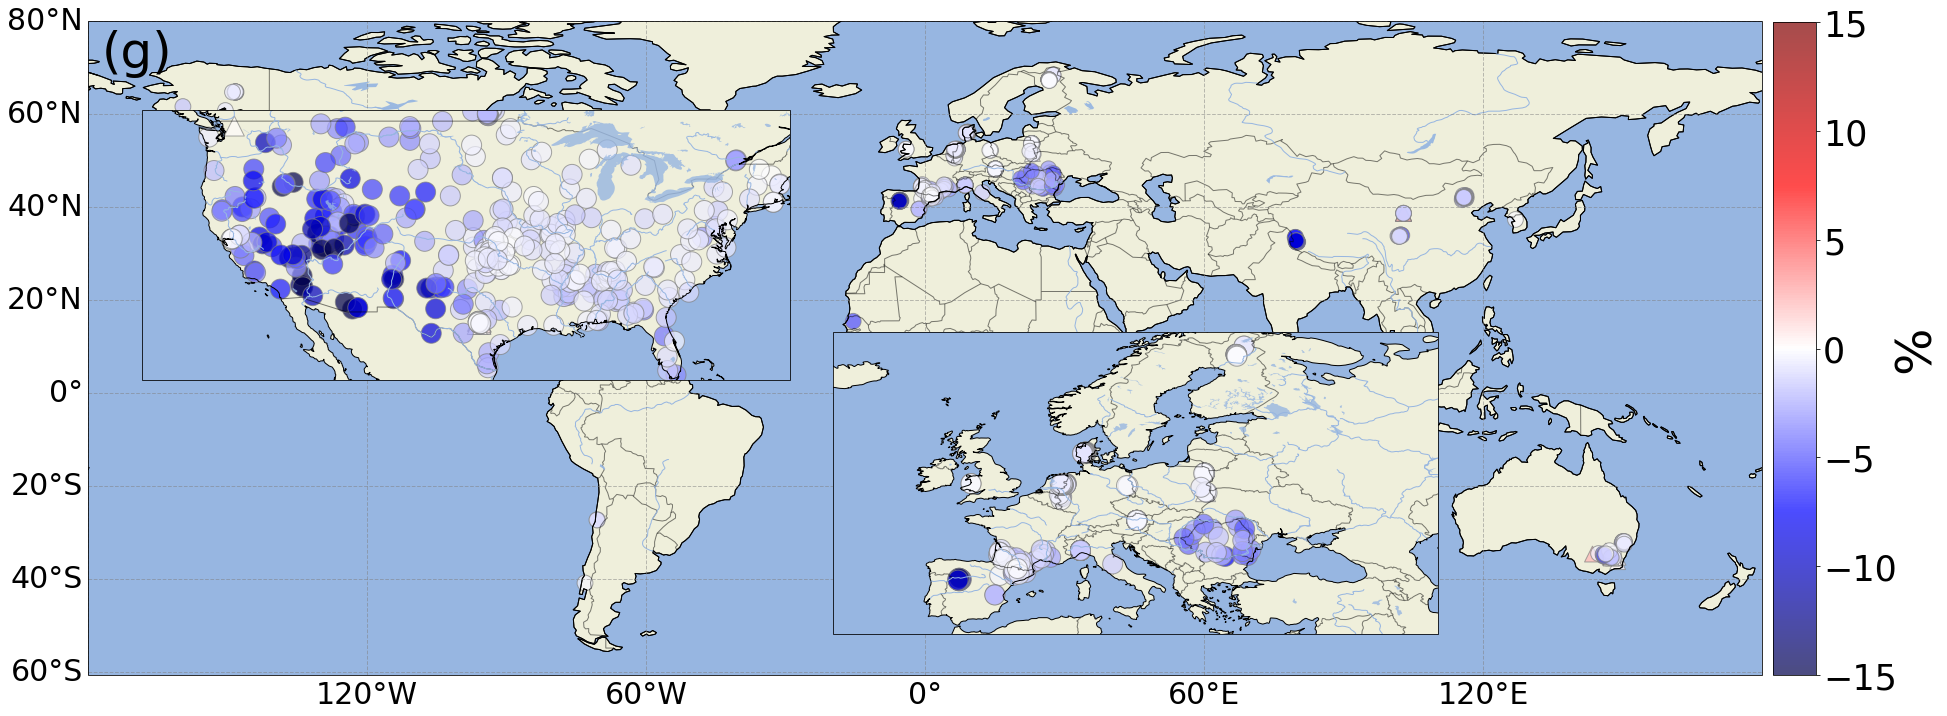

In [365]:
# Fig. 3g
fig ,axs= plt.subplots(figsize=(30, 30), subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_facecolor('white')

cor_p1 = np.array([value > 0 for value in mean_corrected_ratio_all])
cor_n1 = np.array([value <= 0 for value in mean_corrected_ratio_all])

axs.scatter(np.array(lon_all)[cor_p1], np.array(lat_all)[cor_p1], c=np.array(mean_corrected_ratio_all)[cor_p1], cmap='seismic', transform=ccrs.PlateCarree(),s=250, edgecolor='gray',norm=Normalize(-15,15),marker='^',alpha=0.7)
axs.scatter(np.array(lon_all)[cor_n1], np.array(lat_all)[cor_n1], c=np.array(mean_corrected_ratio_all)[cor_n1], cmap='seismic', transform=ccrs.PlateCarree(),s=250, edgecolor='gray',norm=Normalize(-15,15),marker='o',alpha=0.7)

axs.coastlines()
axs.add_feature(cfeature.LAND)
axs.add_feature(cfeature.OCEAN)
axs.add_feature(cfeature.COASTLINE)
axs.add_feature(cfeature.BORDERS, linestyle='-', alpha=.5)
axs.add_feature(cfeature.LAKES, alpha=0.95)
axs.add_feature(cfeature.RIVERS)
axs.set_extent([-180, 150, -60, 80])

gl = axs.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': 30}
gl.ylabel_style = {'size': 30}
axs.text(-177.,70., '(g)', fontsize=50)

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'CONUS'
ax_inset = fig.add_axes([0.15, 0.40, 0.3, 0.3], projection=ccrs.PlateCarree())
ax_inset.set_extent([-130, -70, 25, 50], crs=ccrs.PlateCarree())

ax_inset.coastlines()
ax_inset.add_feature(cfeature.LAND)
ax_inset.add_feature(cfeature.OCEAN)
ax_inset.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset.add_feature(cfeature.RIVERS)

ax_inset.scatter(np.array(lon_all)[cor_p1], np.array(lat_all)[cor_p1], c=np.array(mean_corrected_ratio_all)[cor_p1], cmap='seismic', transform=ccrs.PlateCarree(),s=400, edgecolor='gray',norm=Normalize(-15,15),marker='^',alpha=0.7)
ax_inset.scatter(np.array(lon_all)[cor_n1], np.array(lat_all)[cor_n1], c=np.array(mean_corrected_ratio_all)[cor_n1], cmap='seismic', transform=ccrs.PlateCarree(),s=400, edgecolor='gray',norm=Normalize(-15,15),marker='o',alpha=0.7)

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'EU'
ax_inset2 = fig.add_axes([0.47, 0.35, 0.28, 0.18], projection=ccrs.PlateCarree())
ax_inset2.set_extent([-20, 50, 35, 70], crs=ccrs.PlateCarree())
ax_inset2.coastlines()
ax_inset2.add_feature(cfeature.LAND)
ax_inset2.add_feature(cfeature.OCEAN)
ax_inset2.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset2.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset2.add_feature(cfeature.RIVERS)

ax_inset2.scatter(np.array(lon_all)[cor_p1], np.array(lat_all)[cor_p1], c=np.array(mean_corrected_ratio_all)[cor_p1], cmap='seismic', transform=ccrs.PlateCarree(),s=400, edgecolor='gray',norm=Normalize(-15,15),marker='^',alpha=0.7)
ax_inset2.scatter(np.array(lon_all)[cor_n1], np.array(lat_all)[cor_n1], c=np.array(mean_corrected_ratio_all)[cor_n1], cmap='seismic', transform=ccrs.PlateCarree(),s=400, edgecolor='gray',norm=Normalize(-15,15),marker='o',alpha=0.7)

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'colorbar'
axpos = axs.get_position()
cbar_ax = fig.add_axes([axpos.x0+0.78, axpos.y0-0.0, 0.02, 0.302])
cbar = fig.colorbar(axs.collections[0], cax=cbar_ax, ticks=np.arange(-15,15.1,5),orientation='vertical')
cbar.ax.tick_params(labelsize=35)
cbar.set_label('%', fontsize=50,labelpad=-5)
plt.show()

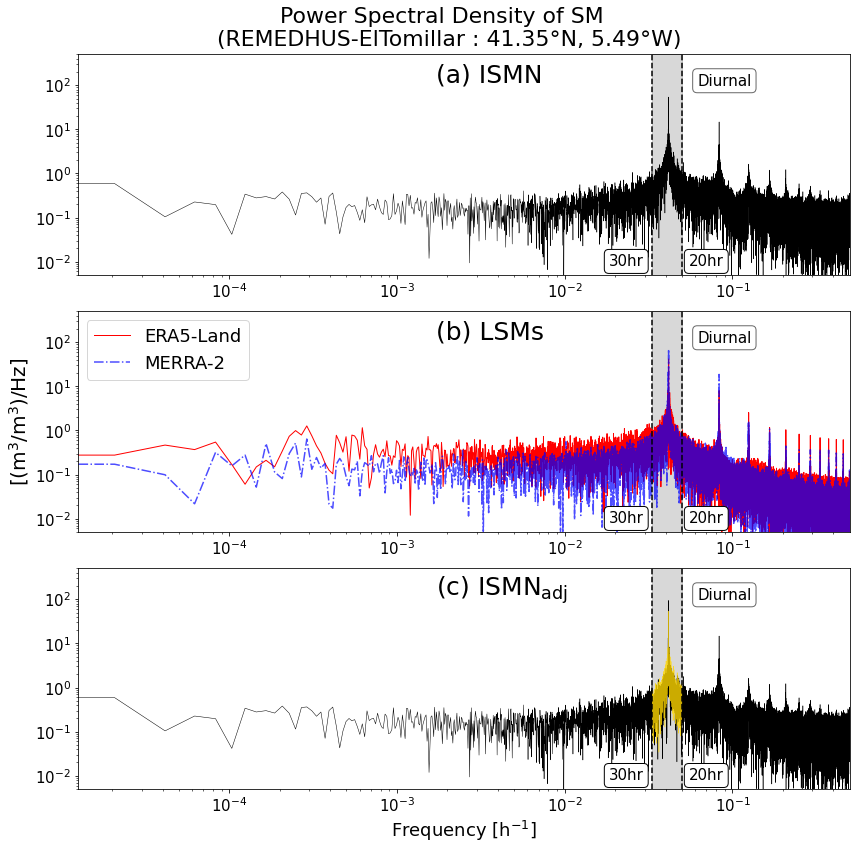

In [40]:
# Fig. 4
fig,axs=plt.subplots(3,1,figsize=(12,12))
fig.set_facecolor('white')
axs[0].plot(freq_ISMN_ano[:len(freq_ISMN_ano)//2], ps_ISMN_ano[:len(freq_ISMN_ano)//2],c='k',linewidth=0.5)
axs[0].axvspan(1/20,1/30, color='gray', alpha=0.3)
axs[0].axvline(1/20, color='k', linestyle='--',linewidth=1.5,alpha=1) 
axs[0].axvline(1/30, color='k', linestyle='--',linewidth=1.5,alpha=1) 
axs[0].text(1/24+0.02,100.,'Diurnal',bbox=bbox_props, fontsize=15)
axs[0].text(1/30-0.015,0.008,'30hr',bbox=bbox_props2, fontsize=15)
axs[0].text(1/20+0.005,0.008,'20hr',bbox=bbox_props2, fontsize=15)
axs[0].set_yscale('log')
axs[0].set_xscale('log')
axs[0].set_ylim(0.005,500)
axs[0].set_xlim(0,np.max(freq_ISMN_ano))
axs[0].tick_params(axis='both', labelsize=15)
axs[0].text(0.0017,120,'(a) ISMN',fontsize=25)

axs[1].plot(freq_ERA_ano[:len(freq_ERA_ano)//2], ps_ERA_ano[:len(freq_ERA_ano)//2],c='red',linewidth=1,label='ERA5-Land')
axs[1].plot(freq_MERRA_ano[:len(freq_MERRA_ano)//2], ps_MERRA_ano[:len(freq_MERRA_ano)//2],c='blue',linewidth=1.5,alpha=0.7,label='MERRA-2', linestyle='-.')
axs[1].axvspan(1/20,1/30, color='gray', alpha=0.3)
axs[1].axvline(1/20, color='k', linestyle='--',linewidth=1.5,alpha=1) 
axs[1].axvline(1/30, color='k', linestyle='--',linewidth=1.5,alpha=1) 
axs[1].text(1/24+0.02,100.,'Diurnal',bbox=bbox_props, fontsize=15)
axs[1].text(1/30-0.015,0.008,'30hr',bbox=bbox_props2, fontsize=15)
axs[1].text(1/20+0.005,0.008,'20hr',bbox=bbox_props2, fontsize=15)
axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_ylabel('[(m$^3$/m$^3$)/Hz]',fontsize=20)
axs[1].legend(loc='upper left', fontsize=18)
axs[1].set_ylim(0.005,500)
axs[1].set_xlim(0,np.max(freq_ISMN_ano))
axs[1].tick_params(axis='both', labelsize=15)
axs[1].text(0.0017,120,'(b) LSMs',fontsize=25)

axs[2].plot(freq_ISMN_ano[:len(freq_ISMN_ano)//2], ps_ano_adj_all[:len(freq_ISMN_ano)//2],c='k',linewidth=0.5)
axs[2].plot(freq_ISMN_ano[:len(freq_ISMN_ano)//2], ps_t[:len(freq_ISMN_ano)//2],c='gold',linewidth=0.5,alpha=0.8)
axs[2].axvspan(1/20,1/30, color='gray', alpha=0.3)
axs[2].axvline(1/20, color='k', linestyle='--',linewidth=1.5,alpha=1) 
axs[2].axvline(1/30, color='k', linestyle='--',linewidth=1.5,alpha=1) 
axs[2].text(1/24+0.02,100.,'Diurnal',bbox=bbox_props, fontsize=15)
axs[2].text(1/30-0.015,0.008,'30hr',bbox=bbox_props2, fontsize=15)
axs[2].text(1/20+0.005,0.008,'20hr',bbox=bbox_props2, fontsize=15)
axs[2].set_yscale('log')
axs[2].set_xscale('log')
axs[2].set_xlabel('Frequency [h$^{-1}$]',fontsize=18)
axs[2].set_ylim(0.005,500)
axs[2].set_xlim(0,np.max(freq_ISMN_ano))
axs[2].tick_params(axis='both', labelsize=15)
axs[2].text(0.0017,120,r'(c) ISMN$_{\text{adj}}$',fontsize=25)

plt.suptitle(f'Power Spectral Density of SM \n ({net_ex}-{st_ex} : {round(lat_ex,2)}°N, {-round(lon_ex,2)}°W)',fontsize=22,x=0.52,y=.98)
plt.tight_layout()
plt.show()

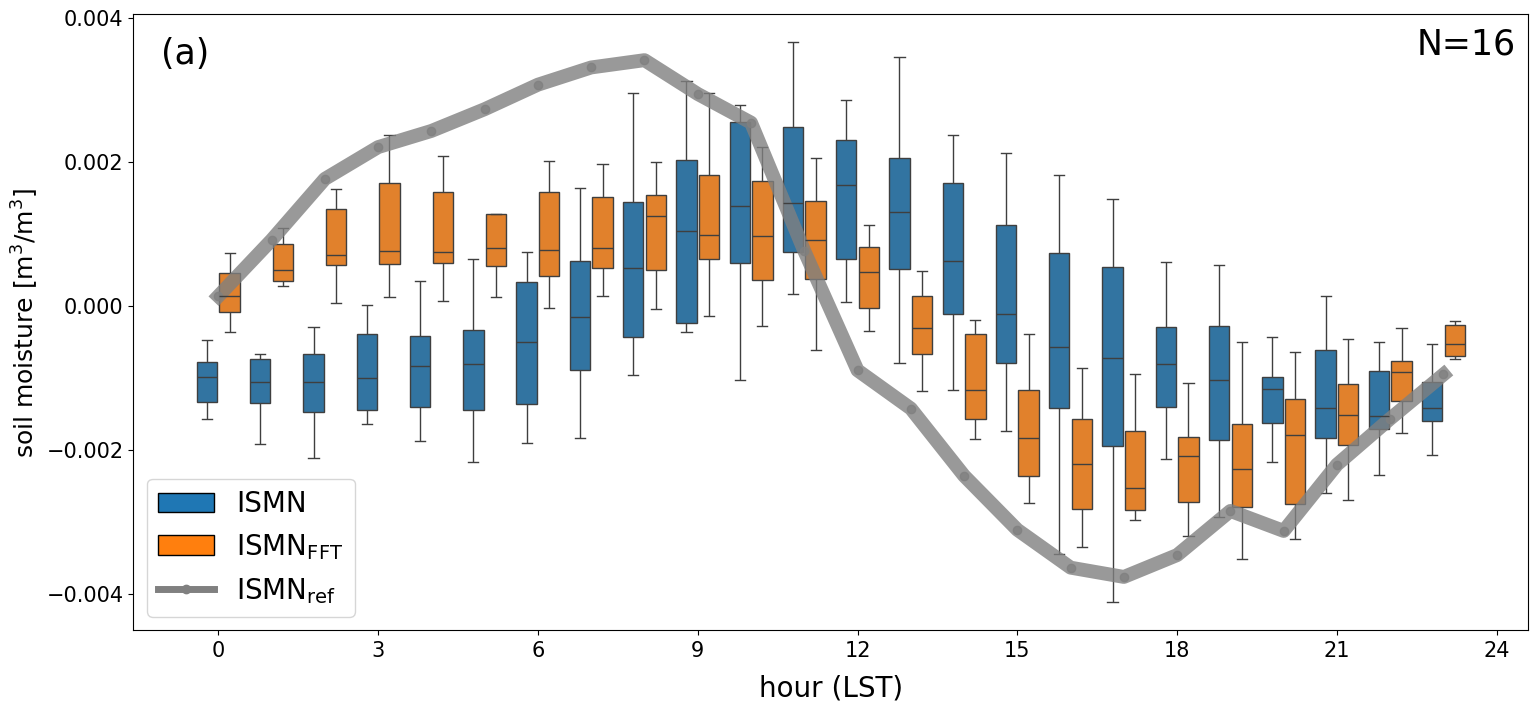

In [1586]:
# Fig. 5a
fig, axs = plt.subplots(1, 1, figsize=(18, 8))
fig.set_facecolor('white')

sns.boxplot(x='hour',y='value',hue='data',data=df_h,width=.85, whis=1., showfliers=False, gap=.1)
med,=plt.plot(median_values.index, median_values.values, marker='o', color='gray', label=r'$\text{ISMN_{ref}}$',linewidth=10,alpha=0.8)
plt.xlabel('hour (LST)',fontsize=20,labelpad=10)
plt.ylabel('soil moisture [m$^3$/m$^3$]',fontsize=18)
plt.yticks([-0.004,-0.002,0,0.002,0.004],fontsize=15)
plt.xticks([0, 3, 6, 9, 12, 15, 18, 21, 24], ['0', '3', '6', '9', '12', '15', '18', '21', '24'], fontsize=15)
plt.legend(fontsize=12,loc='upper left')

ax = plt.gca()  
ax.text(0.02, 0.92, '(a)', fontsize=25, transform=ax.transAxes)

box1 = mpatches.Patch(facecolor='#1f77b4', edgecolor='black', label='ISMN')
box2 = mpatches.Patch(facecolor='#ff7f0e', edgecolor='black', label=r'ISMN$_{\text{FFT}}$')
line = plt.Line2D([0], [0], color='gray', lw=5, marker='o', label=r'ISMN$_{\text{ref}}$')
plt.legend(handles=[box1, box2, line], fontsize=20, loc='lower left')
plt.text(22.5,0.0035,'N=16',fontsize=25)
plt.show()

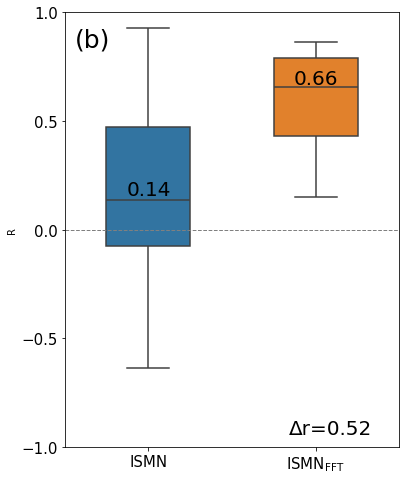

In [85]:
# Fig. 5b
fig, axs = plt.subplots(1, 1, figsize=(6, 8))
fig.set_facecolor('white')

sns.boxplot(x=' ', y='R', hue='t', data=df_cor, width=0.5, legend=False, linewidth=1.5, showfliers=False)
plt.xticks(fontsize=15)
plt.yticks([-1.0, -0.5, 0, 0.5, 1.0],fontsize=15)
plt.ylim(-1.,1.)
plt.axhline(0.0,c='gray',linestyle='--',linewidth=1)
ax = plt.gca()  
ax.text(0.03, 0.92, '(b)', fontsize=25, transform=ax.transAxes)
ax.text(.67, 0.03, f'Δr={round(median_diff,2)}', fontsize=20, transform=ax.transAxes)
ax.text(-.13,.16, f'{np.round(med_ori,2)}', fontsize=20)
ax.text(.87,.67, f'{np.round(med_adj,2)}', fontsize=20)
plt.show()

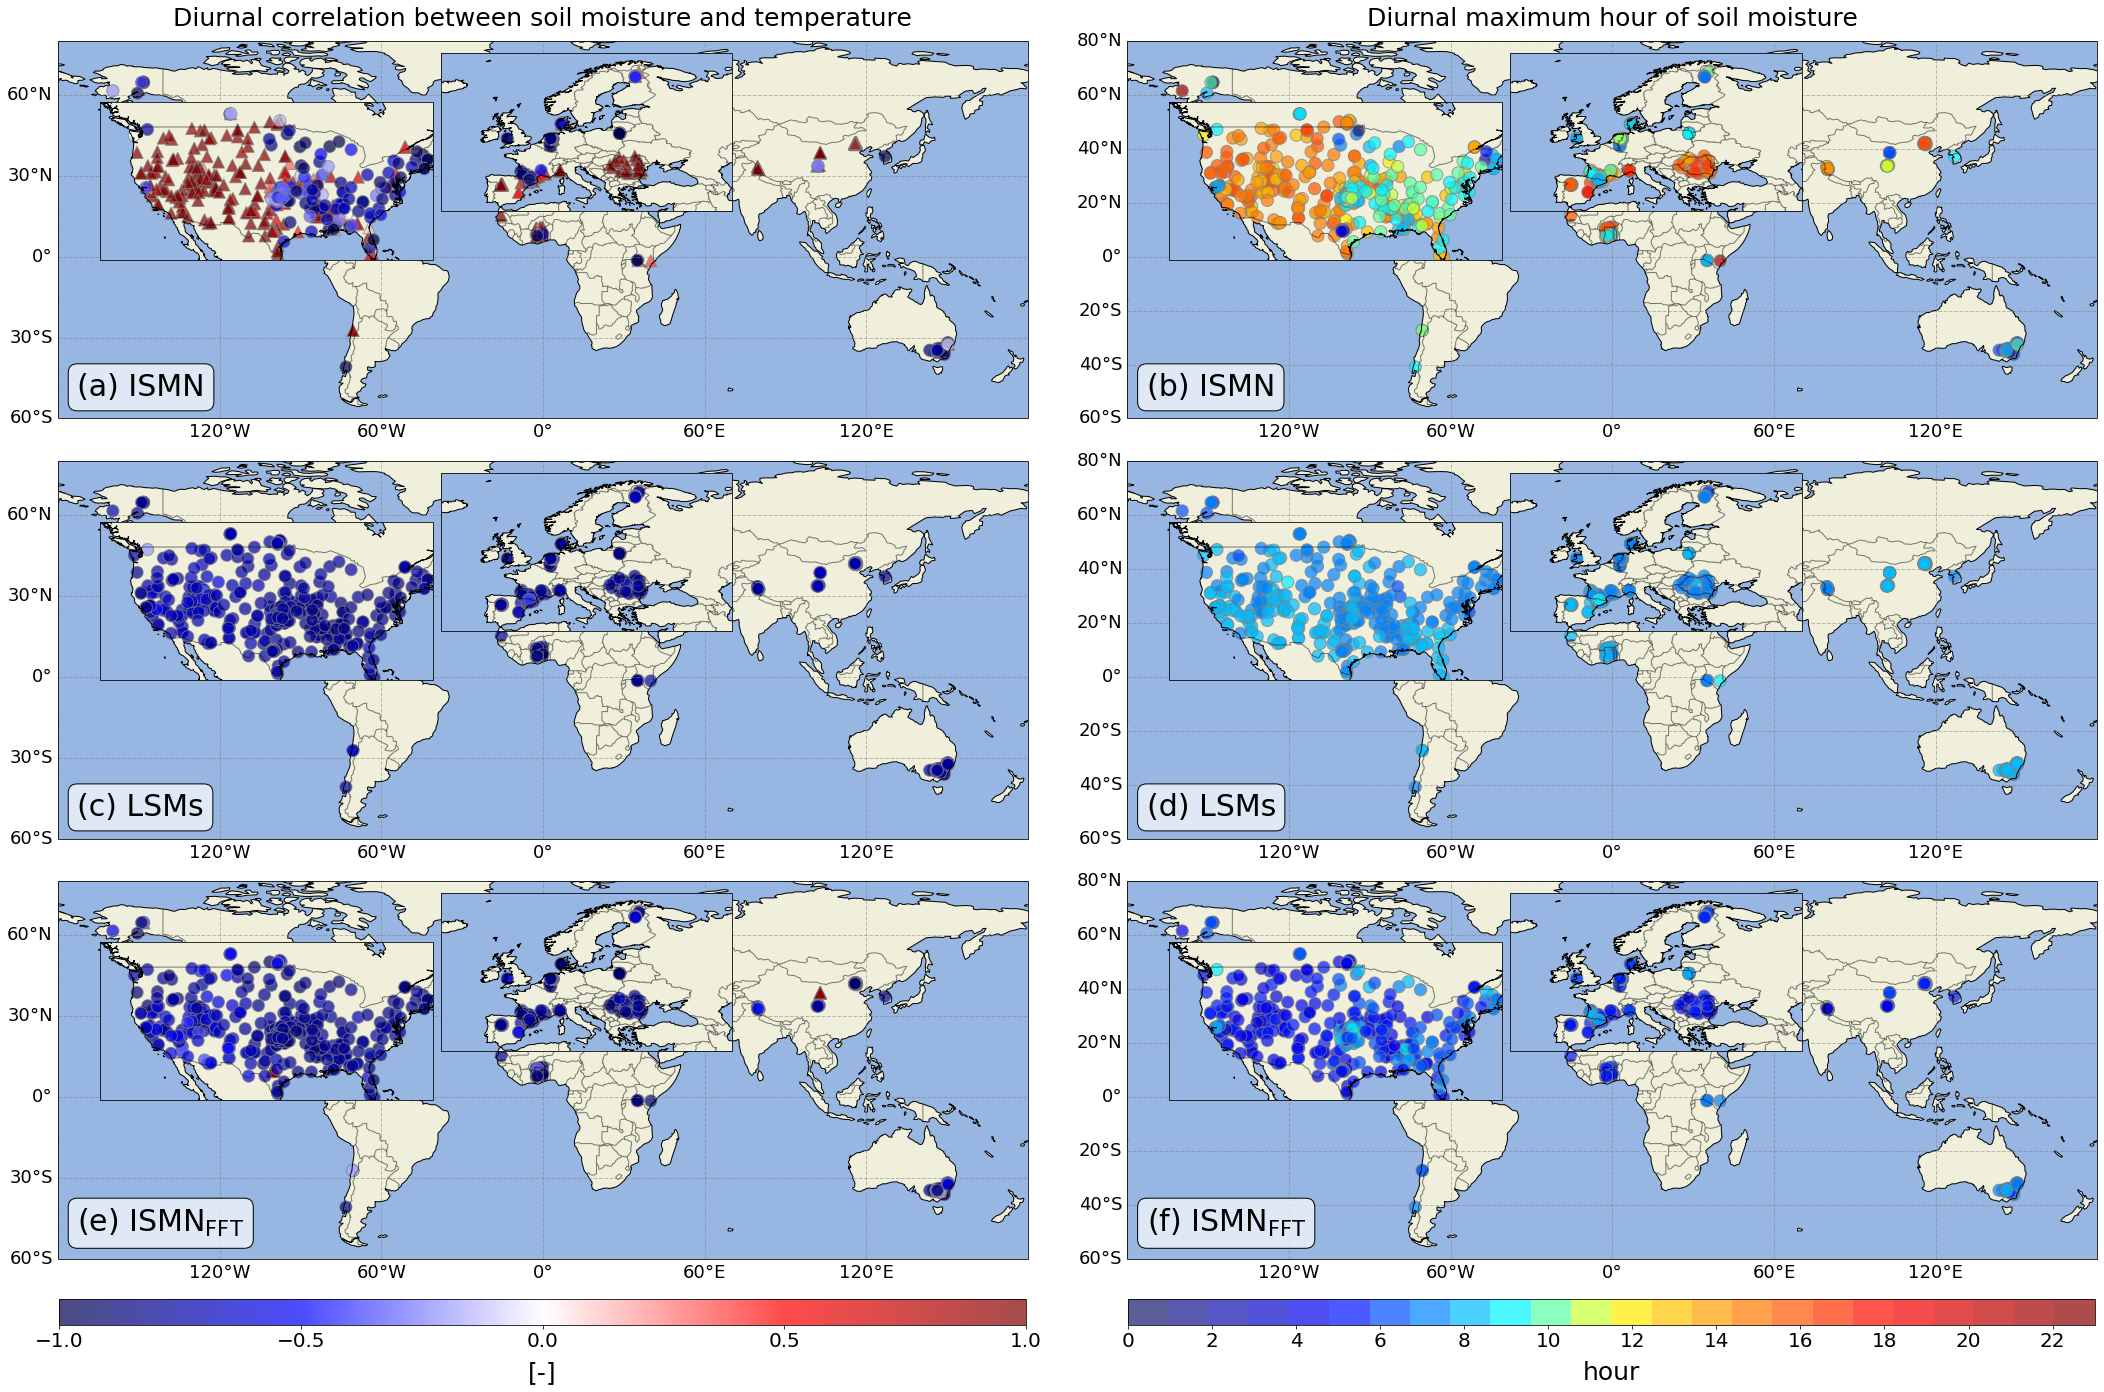

In [383]:
# Fig. 6
fig, axs = plt.subplots(3, 2, figsize=(30, 18),
                        subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_facecolor('white')

axs = axs.flatten()

lon = np.array(lon_all)
lat = np.array(lat_all)
R0   = np.array(R_ISMN_all)
R1   = np.array(R_LSM_all)
R2   = np.array(R_adj_all)

cor_p0 = R0 > 0
cor_n0 = R0 <= 0
cor_p1 = R1 > 0
cor_n1 = R1 <= 0
cor_p2 = R2 > 0
cor_n2 = R2 <= 0

datasets = [(R0, cor_p0, cor_n0, 'ISMN'), (R1, cor_p1, cor_n1, 'LSM'), (R2, cor_p2, cor_n2, 'Adjusted')]
hour_sets = [max_hr_ISMN_all, max_hr_LSM_all, max_hr_adj_all]

norm = Normalize(-1, 1)
for row in range(3):
    R, cor_p, cor_n, title = datasets[row]
    ax_left = axs[row*2]

    sc_corr=draw_main_map(ax_left, f'({chr(97+row*2)}) {title}', R, cor_p, cor_n)
    add_inset(ax_left, [-130, -70, 25, 50], [-0.11, 0.42, 0.65, 0.42], R, cor_p, cor_n)
    add_inset(ax_left, [-20, 50, 35, 70], [0.22, 0.55, 0.65, 0.42], R, cor_p, cor_n)

    ax_right = axs[row*2 + 1]
    values = hour_sets[row]
    sc = draw_hour_map(ax_right, f'({chr(97+row*2+1)})', values)
    add_hour_inset(ax_right, [-130, -70, 25, 50], [-0.11, 0.42, 0.65, 0.42], values)
    add_hour_inset(ax_right, [-20, 50, 35, 70], [0.22, 0.55, 0.65, 0.42],values)


axs[0].text(0.02, 0.06, '(a) ISMN', transform=axs[0].transAxes, fontsize=30, bbox=dict(boxstyle='round', facecolor=(1,1,1,0.7), edgecolor='black'))
axs[2].text(0.02, 0.06, '(c) LSMs', transform=axs[2].transAxes, fontsize=30, bbox=dict(boxstyle='round', facecolor=(1,1,1,0.7), edgecolor='black'))
axs[4].text(0.02,0.07,r'(e) ISMN$_{\text{FFT}}$',transform=axs[4].transAxes,fontsize=30,bbox={'boxstyle': 'round,pad=0.3', 'facecolor': (1, 1, 1, 0.7), 'edgecolor': 'black'})
axs[1].text(0.02, 0.06, '(b) ISMN', transform=axs[1].transAxes, fontsize=30, bbox=dict(boxstyle='round', facecolor=(1,1,1,0.7), edgecolor='black'))
axs[3].text(0.02, 0.06, '(d) LSMs', transform=axs[3].transAxes, fontsize=30, bbox=dict(boxstyle='round', facecolor=(1,1,1,0.7), edgecolor='black'))
axs[5].text(0.02,0.07,r'(f) ISMN$_{\text{FFT}}$',transform=axs[5].transAxes,fontsize=30,bbox={'boxstyle': 'round,pad=0.3', 'facecolor': (1, 1, 1, 0.7), 'edgecolor': 'black'})

axs[0].set_title('Diurnal correlation between soil moisture and temperature', fontsize=25, pad=15)
axs[1].set_title('Diurnal maximum hour of soil moisture', fontsize=25)

axpos4 = axs[4].get_position()
cbar_ax4 = fig.add_axes([axpos4.x0-.092, axpos4.y0 - 0.15, axpos4.width+.105, 0.02])
cbar4 = fig.colorbar(sc_corr, cax=cbar_ax4, ticks=np.arange(-1,1.1,0.5),orientation='horizontal')
cbar4.ax.tick_params(labelsize=20)
cbar4.set_label('[-]', fontsize=25,labelpad=10)

axpos5 = axs[5].get_position()
cbar_ax5 = fig.add_axes([axpos5.x0-.02, axpos5.y0 - 0.15, axpos5.width+.105, 0.02])
cbar5 = fig.colorbar(sc, cax=cbar_ax5, ticks=np.arange(0,23,2),orientation='horizontal')
cbar5.ax.tick_params(labelsize=20)
cbar5.set_label('hour', fontsize=25,labelpad=10)

plt.tight_layout()
plt.show()

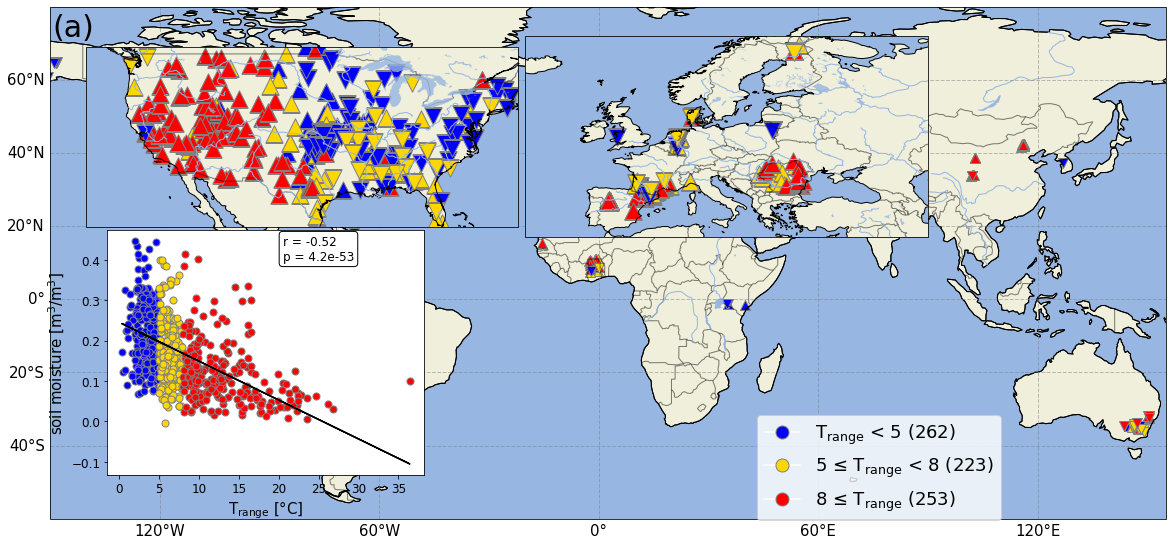

In [39]:
# Fig. 7a
fig ,ax= plt.subplots(figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_facecolor('white')

R_p1 = np.array([value > 0 for value in trange1_ISMN])
R_n1 = np.array([value < 0 for value in trange1_ISMN])
R_p2 = np.array([value > 0 for value in trange2_ISMN])
R_n2 = np.array([value < 0 for value in trange2_ISMN])
R_p3 = np.array([value > 0 for value in trange3_ISMN])
R_n3 = np.array([value < 0 for value in trange3_ISMN])

plt.scatter(trange1_lon[R_p1], trange1_lat[R_p1],transform=cartopy.crs.PlateCarree(), s=100, color='blue',edgecolor='gray', marker='^',)
plt.scatter(trange2_lon[R_p2], trange2_lat[R_p2],transform=cartopy.crs.PlateCarree(),s=100,color='gold',edgecolor='gray', marker='^')
plt.scatter(trange3_lon[R_p3], trange3_lat[R_p3],transform=cartopy.crs.PlateCarree(),s=100,color='red',edgecolor='gray', marker='^')

plt.scatter(trange1_lon[R_n1], trange1_lat[R_n1],transform=cartopy.crs.PlateCarree(), s=100, color='blue',edgecolor='gray', marker='v')
plt.scatter(trange2_lon[R_n2], trange2_lat[R_n2],transform=cartopy.crs.PlateCarree(),s=100,color='gold',edgecolor='gray', marker='v')
plt.scatter(trange3_lon[R_n3], trange3_lat[R_n3],transform=cartopy.crs.PlateCarree(),s=100,color='red',edgecolor='gray', marker='v')

ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=.5)
ax.add_feature(cfeature.LAKES, alpha=0.95)
ax.add_feature(cfeature.RIVERS)
ax.set_extent([-150, 160, -60, 80], crs=ccrs.PlateCarree())
ax.set_xlim(-150, 155)
ax.set_ylim(-60, 80)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': 15}
gl.ylabel_style = {'size': 15}

custom_legend = [
    Line2D([0], [0], marker='o', color='w', label=fr'$\mathrm{{T}}_{{\mathrm{{range}}}}$ < 5 ({len_trange1})',
           markerfacecolor='blue', markersize=13, markeredgecolor='gray'),
    Line2D([0], [0], marker='o', color='w', label=fr'5 ≤ $\mathrm{{T}}_{{\mathrm{{range}}}}$ < 8 ({len_trange2})',
           markerfacecolor='gold', markersize=13, markeredgecolor='gray'),
    Line2D([0], [0], marker='o', color='w', label=fr'8 ≤ $\mathrm{{T}}_{{\mathrm{{range}}}}$ ({len_trange3})',
           markerfacecolor='red', markersize=13, markeredgecolor='gray')]
plt.legend(handles=custom_legend, fontsize=18, bbox_to_anchor=(.86, .22))

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'CONUS'
ax_inset = fig.add_axes([0.15, 0.40, 0.3, 0.38], projection=ccrs.PlateCarree())
ax_inset.set_extent([-130, -70, 25, 50], crs=ccrs.PlateCarree())

ax_inset.coastlines()
ax_inset.add_feature(cfeature.LAND)
ax_inset.add_feature(cfeature.OCEAN)
ax_inset.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset.add_feature(cfeature.RIVERS)

ax_inset.scatter(trange1_lon[R_p1], trange1_lat[R_p1],transform=cartopy.crs.PlateCarree(), s=300, color='blue',edgecolor='gray', marker='^',)
ax_inset.scatter(trange2_lon[R_p2], trange2_lat[R_p2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='^')
ax_inset.scatter(trange3_lon[R_p3], trange3_lat[R_p3],transform=cartopy.crs.PlateCarree(),s=300,color='red',edgecolor='gray', marker='^')

ax_inset.scatter(trange1_lon[R_n1], trange1_lat[R_n1],transform=cartopy.crs.PlateCarree(), s=300, color='blue',edgecolor='gray', marker='v')
ax_inset.scatter(trange2_lon[R_n2], trange2_lat[R_n2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='v')
ax_inset.scatter(trange3_lon[R_n3], trange3_lat[R_n3],transform=cartopy.crs.PlateCarree(),s=300,color='red',edgecolor='gray', marker='v')

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'EU'
ax_inset2 = fig.add_axes([0.455, 0.5, 0.28, 0.18], projection=ccrs.PlateCarree())
ax_inset2.set_extent([-20, 50, 35, 70], crs=ccrs.PlateCarree())

ax_inset2.coastlines()
ax_inset2.add_feature(cfeature.LAND)
ax_inset2.add_feature(cfeature.OCEAN)
ax_inset2.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset2.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset2.add_feature(cfeature.RIVERS)

ax_inset2.scatter(trange1_lon[R_p1], trange1_lat[R_p1],transform=cartopy.crs.PlateCarree(), s=300, color='blue',edgecolor='gray', marker='^',)
ax_inset2.scatter(trange2_lon[R_p2], trange2_lat[R_p2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='^')
ax_inset2.scatter(trange3_lon[R_p3], trange3_lat[R_p3],transform=cartopy.crs.PlateCarree(),s=300,color='red',edgecolor='gray', marker='^')

ax_inset2.scatter(trange1_lon[R_n1], trange1_lat[R_n1],transform=cartopy.crs.PlateCarree(), s=300, color='blue',edgecolor='gray', marker='v')
ax_inset2.scatter(trange2_lon[R_n2], trange2_lat[R_n2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='v')
ax_inset2.scatter(trange3_lon[R_n3], trange3_lat[R_n3],transform=cartopy.crs.PlateCarree(),s=300,color='red',edgecolor='gray', marker='v')

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
plt.text(-102., 70., '(a)', fontsize=30)

# scatter plot
ax_scatter = fig.add_axes([0.165, 0.355, 0.22, 0.17]) 
ax_scatter.scatter(T_range1, sm_mean1, label='Data', alpha=1., c='blue', s=50, edgecolor='gray')
ax_scatter.scatter(T_range2, sm_mean2, label='Data', alpha=1., c='gold', s=50, edgecolor='gray')
ax_scatter.scatter(T_range3, sm_mean3, label='Data', alpha=1., c='red', s=50, edgecolor='gray')
ax_scatter.plot(T_range, sm_pred_range_l, color='k')
ax_scatter.set_xlabel(r'$\text{T}_{\text{range}}$ [°C]', fontsize=15)
ax_scatter.set_ylabel('soil moisture [m$^3$/m$^3$]',fontsize=15)
ax_scatter.tick_params(axis='both', labelsize=12)
ax_scatter.text(20.5,.4, f'r = {r_value_range_l:.2f} \np = {p_value_range_l:.1e}',fontsize=12,bbox={'boxstyle': 'round,pad=0.3', 'facecolor': (1, 1, 1, 1.), 'edgecolor': 'black'})

plt.show()

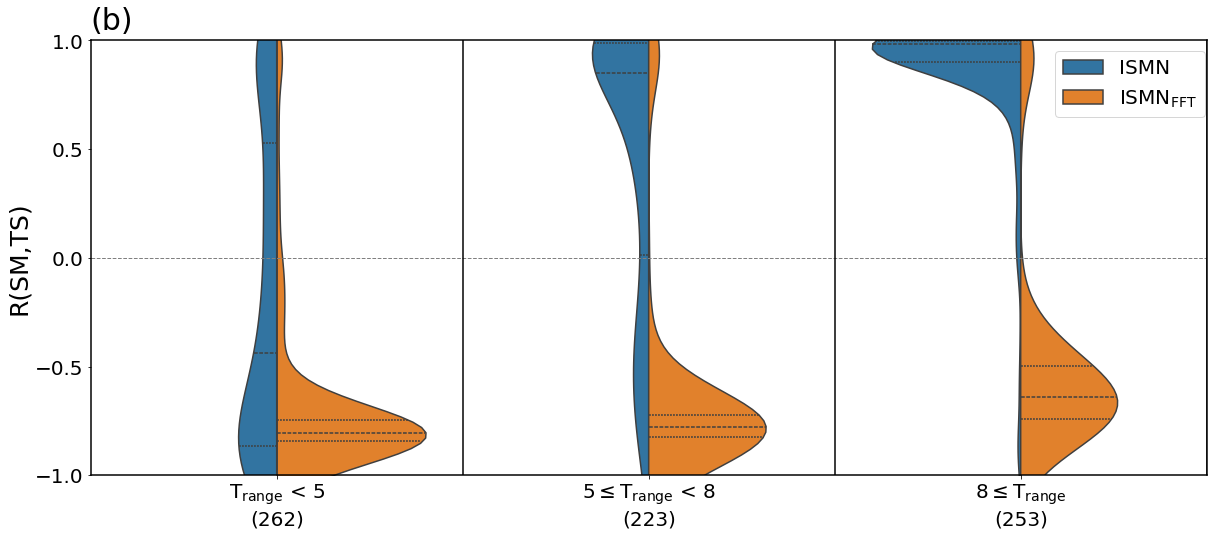

In [137]:
# Fig. 7b
fig, axs = plt.subplots(1, 1, figsize=(20, 8))
fig.set_facecolor('white')

sns.violinplot(x='range', y='R', hue='data', data=R_trange.dropna(), linewidth=1.5, split=True, inner='quart', order=['trange1','trange2','trange3'],ax=axs)
axs.set_xlabel(' ',fontsize=25, labelpad=10)
axs.set_ylabel('R(SM,TS)',fontsize=25)
axs.set_ylim(-1.,1.)
axs.axhline(0.0, linestyle='--', c='gray', linewidth=1)
for x in [0.5, 1.5, 2.5]:
    axs.axvline(x=x, color='k', linestyle='-', linewidth=1.5)
labels = [fr'$\mathrm{{T}}_{{\mathrm{{range}}}}$ < 5' + f'\n({len_trange1})',
    fr'$5 \leq \mathrm{{T}}_{{\mathrm{{range}}}}$ < 8' + f'\n({len_trange2})',
    fr'$8 \leq \mathrm{{T}}_{{\mathrm{{range}}}}$' + f'\n({len_trange3})']
axs.set_xticklabels(labels)
axs.set_yticks([-1.0,-0.5,0,0.5,1])
axs.tick_params(axis='both', labelsize=20)
axs.text(-.5,1.05,'(b)',fontsize=30)
axs.xaxis.label.set_visible(False)
axs.legend(loc='center left', bbox_to_anchor=(.855, .9), fontsize=20)

for spine in axs.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
    
plt.show()

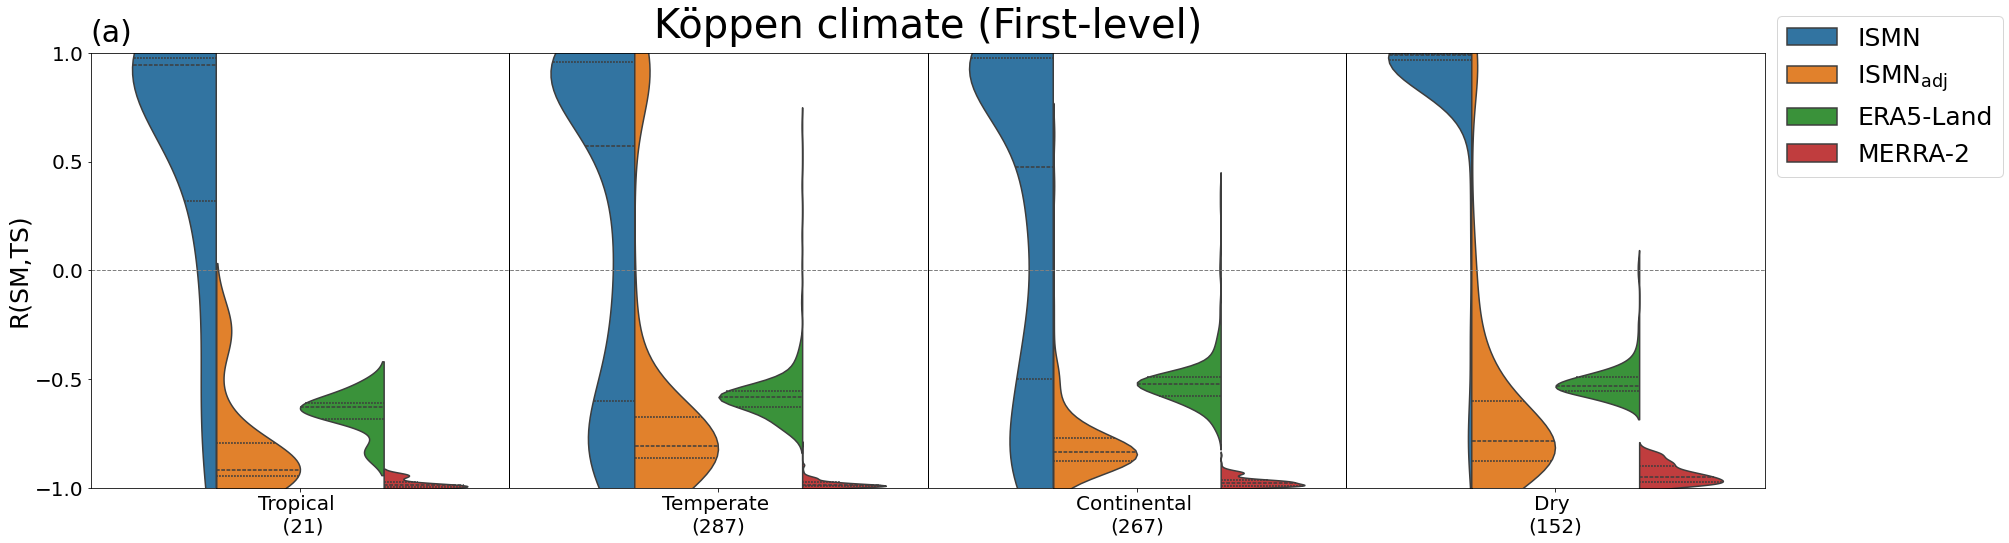

In [97]:
# Fig. 8a
fig, axs = plt.subplots(1, 1, figsize=(30, 8))
fig.set_facecolor('white')

sns.violinplot(x='climate 1st', y='R', hue='data', data=R_df_all_exP, linewidth=1.5, split=True, inner='quart', order=['Tropical','Temperate', 'Continental','Dry'],ax=axs, scale='width')
axs.set_title(r'Köppen climate (First-level)',fontsize=40,pad=15)
axs.xaxis.label.set_visible(False)
axs.set_ylim(-1.,1.)
axs.axhline(0.0, linestyle='--', c='gray', linewidth=1)
for x in [0.5, 1.5, 2.5, 3.5]:
    axs.axvline(x=x, color='k', linestyle='-', linewidth=1)
axs.set_xticklabels([f'Tropical \n ({Tropical_len})',f'Temperate \n({Temperate_len})',f'Continental \n({Continental_len})', f'Dry \n({Dry_len})'], fontsize= 20)
axs.set_yticks([-1.0,-0.5,0,0.5,1])
axs.tick_params(axis='both', labelsize=20)
axs.text(-.5,1.05,'(a)',fontsize=30)
axs.set_ylabel('R(SM,TS)',fontsize=25)
handles, labels = axs.get_legend_handles_labels()
axs.legend(handles[:4], labels[:4], loc='center left', bbox_to_anchor=(1., .9), fontsize=25)

plt.show()

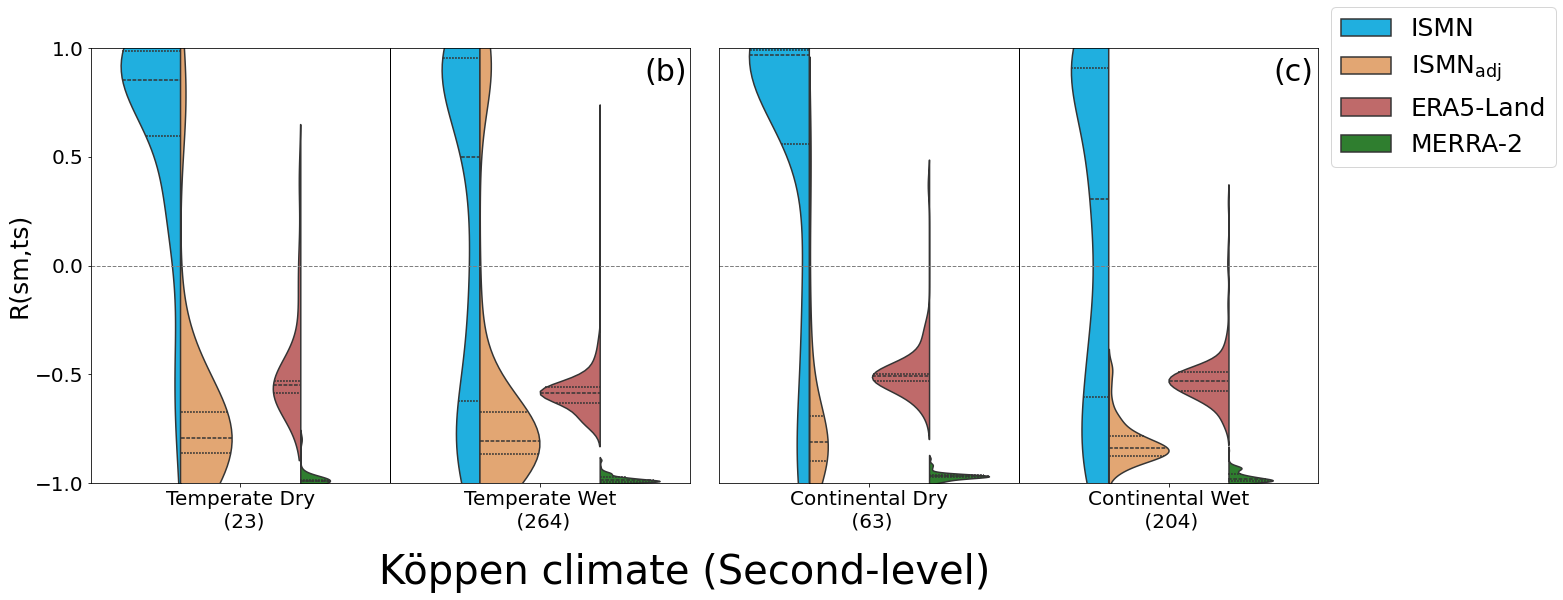

In [98]:
# Fig. 8b & 8c
fig, axs = plt.subplots(1, 2, figsize=(22, 8),gridspec_kw={'wspace': 0.05})
fig.set_facecolor('white')

'(b) ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
sns.violinplot(x='climate 2nd', y='R', hue='data', data=R_df_all_Tem, palette={'ISMN': 'deepskyblue', r'ISMN$_{\text{adj}}$': 'sandybrown', 'ERA5-Land': 'indianred', 'MERRA-2': 'forestgreen'},linewidth=1.5, split=True, inner='quart', order=['Temperate Dry','Temperate Wet'],ax=axs[0])
axs[0].set_xlabel('')
axs[0].set_ylim(-1.,1.)
axs[0].axhline(0.0, linestyle='--', c='gray', linewidth=1)
for x in [0.5, 1.5]:
    axs[0].axvline(x=x, color='k', linestyle='-', linewidth=1)
axs[0].set_xticklabels([f'Temperate Dry\n ({Tem_dry_len2})',f'Temperate Wet\n ({Tem_wet_len2})'], fontsize= 20)
axs[0].set_yticks([-1.0,-0.5,0,0.5,1])
axs[0].tick_params(axis='both', labelsize=20)
axs[0].text(1.35,.85,'(b)',fontsize=30)
axs[0].set_ylabel('R(sm,ts)',fontsize=25)
axs[0].legend().set_visible(False)

'(c) ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
sns.violinplot(x='climate 2nd', y='R', hue='data', data=R_df_all_Con, palette={'ISMN': 'deepskyblue', r'ISMN$_{\text{adj}}$': 'sandybrown', 'ERA5-Land': 'indianred', 'MERRA-2': 'forestgreen'},linewidth=1.5, split=True, inner='quart', order=['Continental Dry','Continental Wet'],ax=axs[1])
axs[1].set_xlabel('')
axs[1].set_ylim(-1.,1.)
axs[1].axhline(0.0, linestyle='--', c='gray', linewidth=1)
for x in [0.5, 1.5]:
    axs[1].axvline(x=x, color='k', linestyle='-', linewidth=1)
axs[1].set_xticklabels([f'Continental Dry\n ({Con_dry_len2})',f'Continental Wet\n ({Con_wet_len2})'], fontsize= 20)
axs[1].set_yticks([-1.0,-0.5,0,0.5,1])
axs[1].tick_params(axis='both', labelsize=20)
axs[1].text(1.35,.85,'(c)',fontsize=30)
axs[1].yaxis.label.set_visible(False)
axs[1].yaxis.set_visible(False)
axs[1].legend(loc='center left', bbox_to_anchor=(1., 0.91), fontsize=25)

fig.text(0.5, -0.05, 'Köppen climate (Second-level)', ha='center', fontsize=40)
plt.tight_layout()
plt.show()

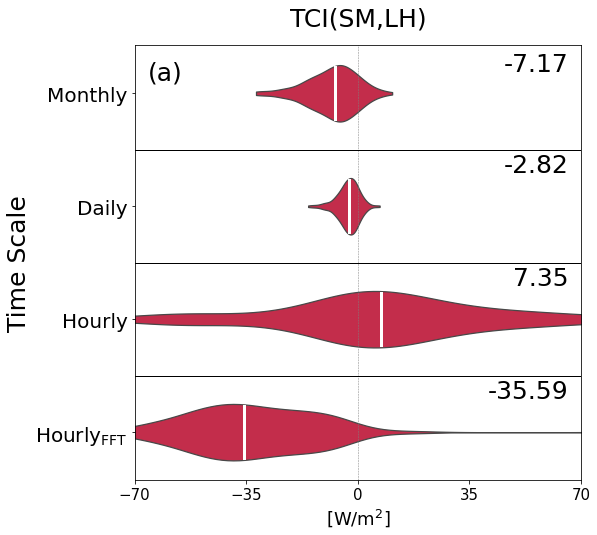

In [59]:
# Fig. 9a
category_sizes = R_violin.groupby('time').size()

max_size = category_sizes.max()
categoryidths = category_sizes / (2*max_size) 

fig, ax = plt.subplots(figsize=(8, 8))
fig.set_facecolor('white')

for i, (category, data) in enumerate(TCI_violin.groupby('time')):
    sns.violinplot(
        data=data,
        x='R',
        y=np.full(len(data), category),
        color='crimson',
        inner=None,
        width=categoryidths[category], 
        ax=ax,
        order=['Monthly','Daily','Hourly','Adjust'],
        cut=0,
        legend=False)

plt.xticks([-70,-35,0,35,70],fontsize=15)
plt.xlim(-70,70)
categories = ['Monthly', 'Daily', 'Hourly', r'$\mathrm{Hourly_{FFT}}$'] 
plt.yticks(range(len(categories)), categories, fontsize=20)
plt.ylabel('Time Scale', fontsize=25)
plt.xlabel(r'$\mathrm{[W/m^2]}$', fontsize=18)
plt.axvline(0,linestyle='--',c='gray',linewidth=.5)
plt.axhline(0.5,c='k',linewidth=1.)
plt.axhline(1.5,c='k',linewidth=1.)
plt.axhline(2.5,c='k',linewidth=1.)
plt.title('TCI(SM,LH)',fontsize=25,pad=20)

plt.text(66.,0-.20,f'{TCI_m_med: .2f}',fontsize=25, c='k', ha='right')
plt.text(66.,1-.30,f'{TCI_d_med: .2f}',fontsize=25, c='k', ha='right')
plt.text(66.,2-.30,f'{TCI_h_med: .2f}',fontsize=25, c='k', ha='right')
plt.text(66.,3-.30,f'{TCI_a_med: .2f}',fontsize=25, c='k', ha='right')

ax = plt.gca()  
ax.text(0.03, 0.92, '(a)', fontsize=25, transform=ax.transAxes)

ax.plot([TCI_m_med, TCI_m_med], [-0.23, 0.23], color='white', linewidth=3)
ax.plot([TCI_d_med, TCI_d_med], [1-0.23, 1+0.23], color='white', linewidth=3)
ax.plot([TCI_h_med, TCI_h_med], [2-0.23, 2+0.23], color='white', linewidth=3)
ax.plot([TCI_a_med, TCI_a_med], [3-0.23, 3+0.23], color='white', linewidth=3)

plt.show()

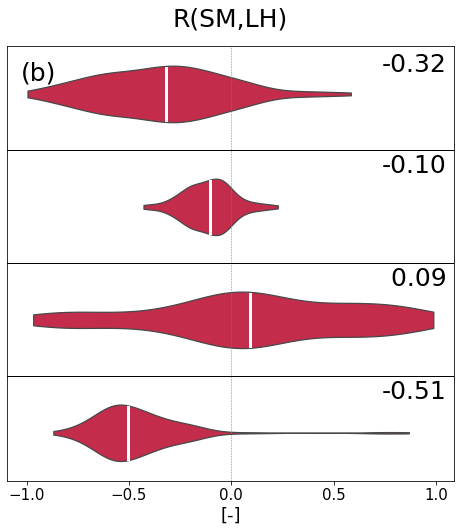

In [912]:
# Fig. 9b
category_sizes = R_violin.groupby('time').size()

max_size = category_sizes.max()
category_widths = category_sizes / (2*max_size)

fig, ax = plt.subplots(figsize=(8, 8))
fig.set_facecolor('white')

for i, (category, data) in enumerate(R_violin.groupby('time')):
    sns.violinplot(
        data=data,
        x='R',
        y=np.full(len(data), category),
        color='crimson',
        inner=None,
        width=category_widths[category],
        ax=ax,
        order=['Monthly','Daily','Hourly','Adjust'],
        cut=0,
        legend=False)

plt.xticks([-1.,-.5,0.,.5,1.],fontsize=15)
ax.yaxis.set_visible(False)
plt.xlabel('[-]', fontsize=18)
plt.axvline(0,linestyle='--',c='gray',linewidth=.5)
plt.axhline(0.5,c='k',linewidth=1.)
plt.axhline(1.5,c='k',linewidth=1.)
plt.axhline(2.5,c='k',linewidth=1.)
plt.title('R(SM,LH)',fontsize=25,pad=20)

plt.text(1.05,0-.20,f'{R_m_med: .2f}',fontsize=25, c='k', ha='right')
plt.text(1.05,1-.30,f'{R_d_med: .2f}',fontsize=25, c='k', ha='right')
plt.text(1.05,2-.30,f'{R_h_med: .2f}',fontsize=25, c='k', ha='right')
plt.text(1.05,3-.30,f'{R_a_med: .2f}',fontsize=25, c='k', ha='right')

ax = plt.gca()  
ax.text(0.03, 0.92, '(b)', fontsize=25, transform=ax.transAxes)

ax.plot([R_m_med, R_m_med], [-0.23, 0.23], color='white', linewidth=3)
ax.plot([R_d_med, R_d_med], [1-0.23, 1+0.23], color='white', linewidth=3)
ax.plot([R_h_med, R_h_med], [2-0.23, 2+0.23], color='white', linewidth=3)
ax.plot([R_a_med, R_a_med], [3-0.23, 3+0.23], color='white', linewidth=3)
plt.show()

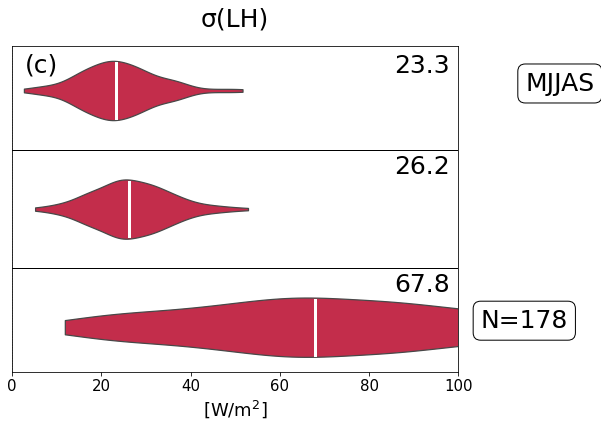

In [248]:
# Fig. 9c
category_sizes = R_violin.groupby('time').size()

max_size = category_sizes.max()
categoryidths = category_sizes / (2*max_size)

fig, ax = plt.subplots(figsize=(8, 6))
fig.set_facecolor('white')

for i, (category, data) in enumerate(std_violin.groupby('time')):
    sns.violinplot(
        data=data,
        x='std',
        y=np.full(len(data), category),
        color='crimson',
        inner=None,
        width=categoryidths[category],
        ax=ax,
        order=['Monthly','Daily','Hourly'],
        cut=0)

plt.xticks(fontsize=15)
plt.xlim(0,100)
ax.yaxis.set_visible(False)
plt.xlabel(r'$\mathrm{[W/m^2]}$', fontsize=18)
plt.axvline(0,linestyle='--',c='gray',linewidth=.5)
plt.axhline(0.5,c='k',linewidth=1.)
plt.axhline(1.5,c='k',linewidth=1.)
plt.title('σ(LH)',fontsize=25,pad=20)

plt.text(98.,0-.15,f'{round(std_m_med, 1)}',fontsize=25, c='k', ha='right')
plt.text(98.,1-.30,f'{round(std_d_med, 1)}',fontsize=25, c='k', ha='right')
plt.text(98.,2-.30,f'{round(std_h_med, 1)}',fontsize=25, c='k', ha='right')

plt.text(105.,2,'N=178',fontsize=25, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.text(115.,0,'MJJAS',fontsize=25, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

ax = plt.gca()  
ax.text(0.03, 0.92, '(c)', fontsize=25, transform=ax.transAxes)

ax.plot([std_m_med, std_m_med], [-0.23, 0.23], color='white', linewidth=3)
ax.plot([std_d_med, std_d_med], [1-0.23, 1+0.23], color='white', linewidth=3)
ax.plot([std_h_med, std_h_med], [2-0.23, 2+0.23], color='white', linewidth=3)
plt.show()

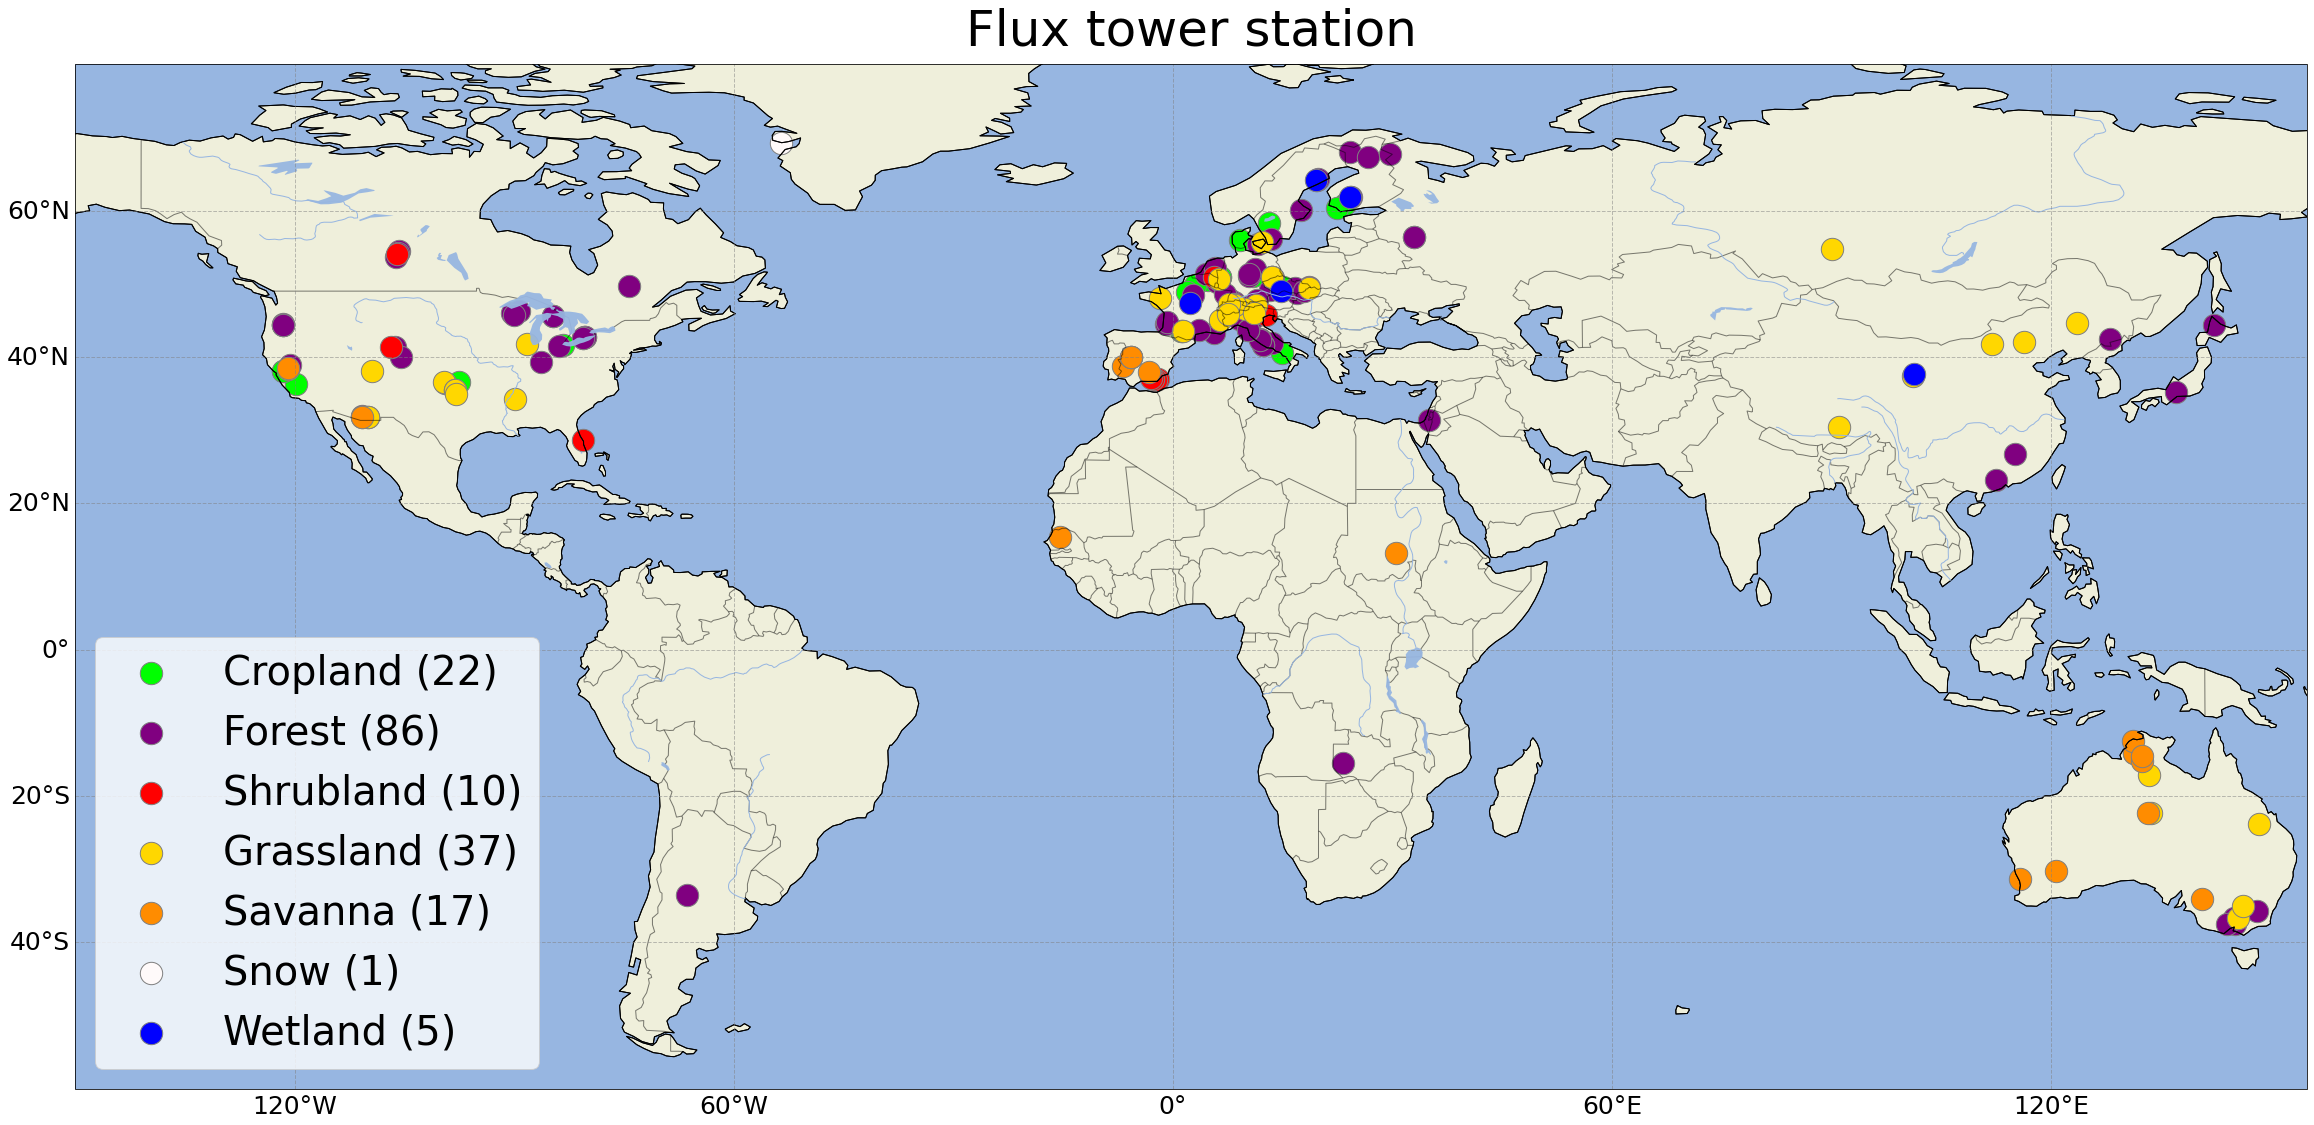

In [21]:
# Fig. S1
fig ,ax= plt.subplots(figsize=(40, 25), subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_facecolor('white')

plt.scatter(lc_lon['lon_Cropland'], lc_lat['lat_Cropland'], transform=cartopy.crs.PlateCarree(), s=500, color='lime',edgecolor='gray', label='Cropland ({})'.format(len(lc_lon["lon_Cropland"])))
plt.scatter(lc_lon['lon_Forest'], lc_lat['lat_Forest'], transform=cartopy.crs.PlateCarree(),s=500,color='purple',edgecolor='gray',label='Forest ({})'.format(len(lc_lon["lon_Forest"])))
plt.scatter(lc_lon['lon_Shrubland'], lc_lat['lat_Shrubland'], transform=cartopy.crs.PlateCarree(),s=500,color='red',edgecolor='gray',label='Shrubland ({})'.format(len(lc_lon["lon_Shrubland"])))
plt.scatter(lc_lon['lon_Grassland'], lc_lat['lat_Grassland'], transform=cartopy.crs.PlateCarree(),s=500,color='gold',edgecolor='gray',label='Grassland ({})'.format(len(lc_lon["lon_Grassland"])))
plt.scatter(lc_lon['lon_Savanna'], lc_lat['lat_Savanna'], transform=cartopy.crs.PlateCarree(),s=500,color='darkorange',edgecolor='gray',label='Savanna ({})'.format(len(lc_lon["lon_Savanna"])))
plt.scatter(lc_lon['lon_Snow'], lc_lat['lat_Snow'], transform=cartopy.crs.PlateCarree(),s=500,color='snow',edgecolor='gray',label='Snow ({})'.format(len(lc_lon["lon_Snow"])))
plt.scatter(lc_lon['lon_Wetland'], lc_lat['lat_Wetland'], transform=cartopy.crs.PlateCarree(),s=500,color='blue',edgecolor='gray',label='Wetland ({})'.format(len(lc_lon["lon_Wetland"])))

ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=.5)
ax.add_feature(cfeature.LAKES, alpha=0.95)
ax.add_feature(cfeature.RIVERS)
ax.set_extent([-150, 160, -60, 80], crs=ccrs.PlateCarree())
ax.set_xlim(-150, 155)
ax.set_ylim(-60, 80)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': 25}
gl.ylabel_style = {'size': 25}

plt.title('Flux tower station',fontsize=50,pad=20)
plt.legend(loc='lower left',fontsize=40)

plt.show()

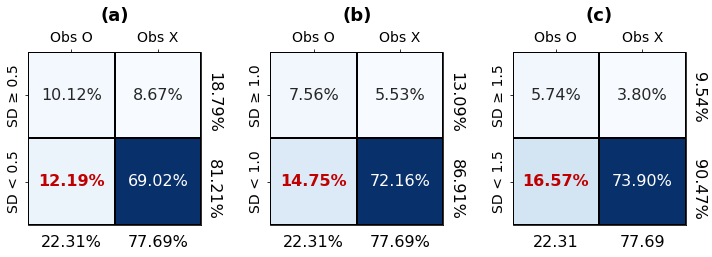

In [106]:
# Fig. S2
fig, axs = plt.subplots(1,3,figsize=(10, 5))
fig.set_facecolor('white')

annot_05 = pivot_05.map(lambda x: f'{x:.2f}%')
sns.heatmap(pivot_05, annot=annot_05, fmt='', cmap='Blues', ax=axs[0], cbar=False, linewidths=2, linecolor='black', square=True, annot_kws={"size": 16})
axs[0].xaxis.tick_top()
axs[0].xaxis.set_label_position('top')
axs[0].xaxis.label.set_size(14)
axs[0].set_xlabel('')
axs[0].set_xticklabels(['Obs O','Obs X'], fontsize=14)
axs[0].yaxis.label.set_size(14)
axs[0].set_yticklabels(['SD ≥ 0.5','SD < 0.5'], fontsize=14)
axs[0].set_ylabel('')
axs[0].set_title('(a)',fontsize=18, pad=10, weight='bold')
axs[0].texts[2].set_fontweight('bold')
axs[0].texts[2].set_color('#c00000')

secax = axs[0].secondary_xaxis('bottom')
secax.set_xticks([0.5, 1.5])
secax.set_xticklabels(['22.31%', '77.69%'], fontsize=16)
secax.set_xlabel('')
secax.tick_params(length=0, pad=10)

secay = axs[0].secondary_yaxis('right')
secay.set_yticks([0.3, 1.3])
secay.set_yticklabels(['18.79%', '81.21%'], fontsize=16, rotation=-90)
secay.set_ylabel('')
secay.tick_params(length=0, pad=5)

annot_10 = pivot_10.map(lambda x: f'{x:.2f}%')
sns.heatmap(pivot_10, annot=annot_10, fmt='', cmap='Blues', ax=axs[1], cbar=False, linewidths=2, linecolor='black', square=True, annot_kws={"size": 16})
axs[1].xaxis.tick_top()
axs[1].xaxis.set_label_position('top')
axs[1].xaxis.label.set_size(14)
axs[1].set_xticklabels(['Obs O','Obs X'], fontsize=14)
axs[1].set_xlabel('')
axs[1].yaxis.label.set_size(14)
axs[1].set_yticklabels(['SD ≥ 1.0','SD < 1.0'], fontsize=14)
axs[1].set_ylabel('')
axs[1].set_title('(b)',fontsize=18, pad=10, weight='bold')
axs[1].texts[2].set_fontweight('bold')
axs[1].texts[2].set_color('#c00000')

secax = axs[1].secondary_xaxis('bottom')
secax.set_xticks([0.5, 1.5])
secax.set_xticklabels(['22.31%', '77.69%'], fontsize=16)
secax.set_xlabel('')
secax.tick_params(length=0, pad=10)

secay = axs[1].secondary_yaxis('right')
secay.set_yticks([0.3, 1.3])
secay.set_yticklabels(['13.09%', '86.91%'], fontsize=16, rotation=-90)
secay.set_ylabel('')
secay.tick_params(length=0, pad=5)

annot_15 = pivot_15.map(lambda x: f'{x:.2f}%')
sns.heatmap(pivot_15, annot=annot_15, fmt='', cmap='Blues', ax=axs[2], cbar=False, linewidths=2, linecolor='black', square=True, annot_kws={"size": 16})
axs[2].xaxis.tick_top()
axs[2].xaxis.set_label_position('top')
axs[2].xaxis.label.set_size(14)
axs[2].set_xlabel('')
axs[2].set_xticklabels(['Obs O','Obs X'], fontsize=14)
axs[2].yaxis.label.set_size(14)
axs[2].set_yticklabels(['SD ≥ 1.5','SD < 1.5'], fontsize=14)
axs[2].set_ylabel('')
axs[2].set_title('(c)',fontsize=18, pad=10, weight='bold')
axs[2].texts[2].set_fontweight('bold')
axs[2].texts[2].set_color('#c00000')

secax = axs[2].secondary_xaxis('bottom')
secax.set_xticks([0.5, 1.5])
secax.set_xticklabels(['22.31', '77.69'], fontsize=16)
secax.set_xlabel('')
secax.tick_params(length=0, pad=10)

secay = axs[2].secondary_yaxis('right')
secay.set_yticks([0.3, 1.3])
secay.set_yticklabels(['9.54%', '90.47%'], fontsize=16, rotation=-90)
secay.set_ylabel('')
secay.tick_params(length=0, pad=5)

plt.tight_layout()
plt.subplots_adjust(wspace=0.4)
plt.show()

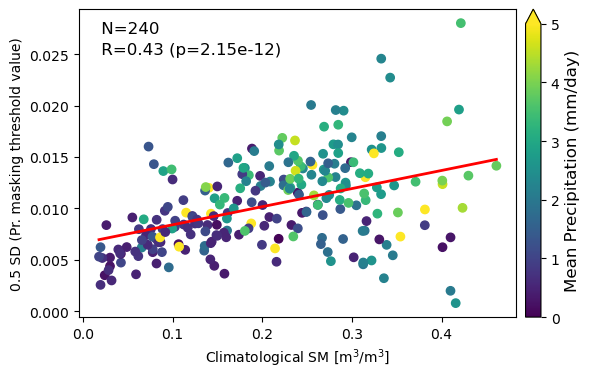

In [1440]:
# Fig. S3
fig = plt.figure(figsize=(6, 4))
fig.set_facecolor('white')

sc = plt.scatter(cli_sm, std, c=mean_p, cmap='viridis', vmin=0, vmax=5)
plt.plot(x_line, y_line, color='red', linewidth=2)
plt.xlabel('Climatological SM [m$^3$/m$^3$]')
plt.ylabel('0.5 SD (Pr. masking threshold value)',fontsize=10)
plt.text(0.015, 0.025, f" N=240\n R={round(r,2)} (p={p:.2e})", fontsize=12, linespacing=1.5)
cbar = plt.colorbar(sc, fraction=0.04, pad=0.02, extend='max')
cbar.set_label('Mean Precipitation (mm/day)', fontsize=12)
cbar.ax.tick_params(labelsize=10)
plt.show()

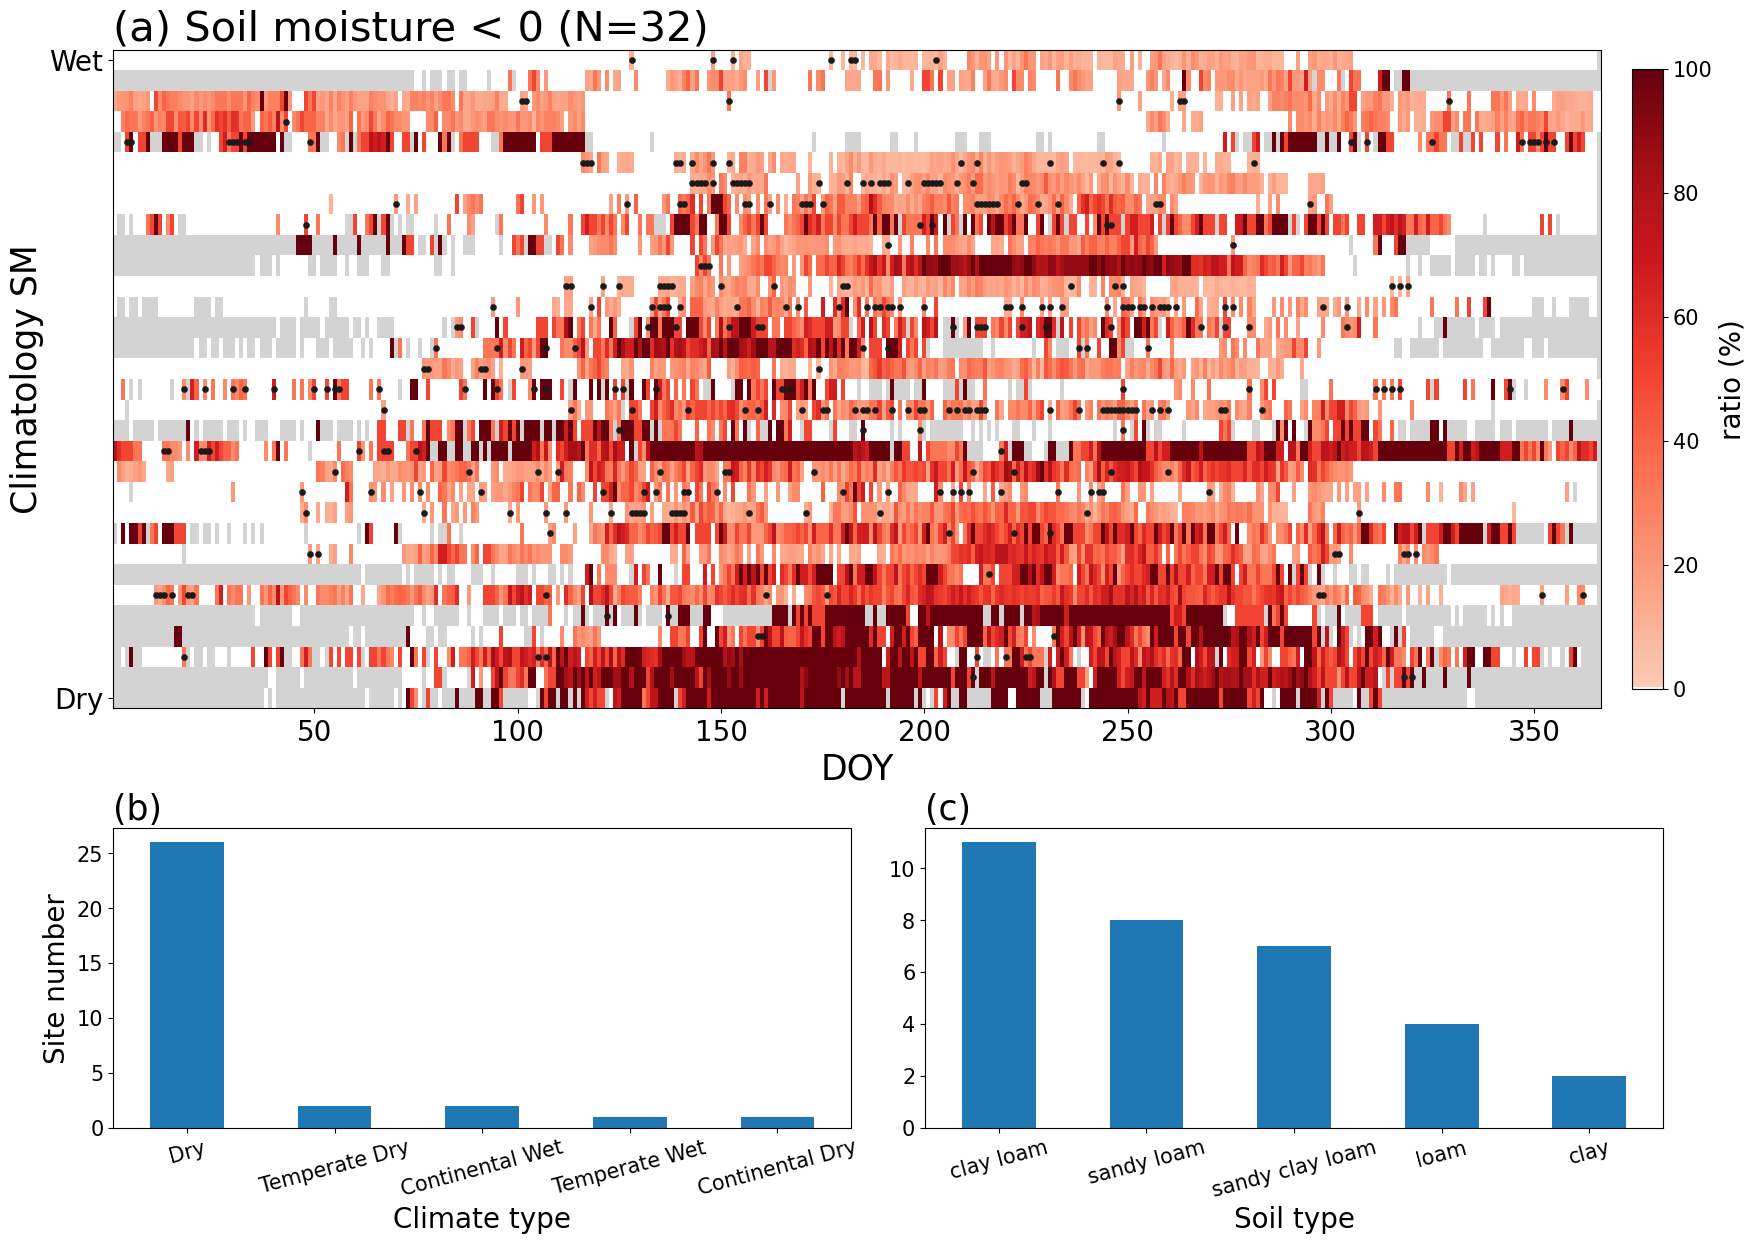

In [1452]:
# Fig. S4
fig = plt.figure(figsize=(20, 14))
fig.set_facecolor('white')

plt.style.use('default')

gs = gridspec.GridSpec(2, 2, height_ratios=[2.2, 1.], hspace=0.25, wspace=0.1)

ax0 = fig.add_subplot(gs[0, :])
im = ax0.pcolormesh(ratio_mat.columns, ratio_mat.index, ratio_mat.values, cmap=cmap, vmin=0, vmax=100)

cbar = plt.colorbar(im, ax=ax0, fraction=0.02, pad=0.02)
cbar.set_label('ratio (%)', fontsize=20)
cbar.ax.tick_params(labelsize=15)

ax0.tick_params(axis='x', labelsize=20)
ax0.set_xlabel('DOY', fontsize=25)
ax0.set_ylabel('Climatology SM', fontsize=25)
ax0.set_yticks([ratio_mat.index.min(), ratio_mat.index.max()])
ax0.set_yticklabels(['Dry', 'Wet'], fontsize=20)
ax0.set_title('(a) Soil moisture < 0 (N=32)', fontsize=30, loc='left')

markers = {1: {'marker':'o', 'color':'k'}}

for state, cfg in markers.items():
    y, x = np.where(state_mat.values == state)
    ax0.scatter(ratio_mat.columns[x], ratio_mat.index[y], marker=cfg['marker'], s=20, c=cfg['color'], linewidths=0.3)

ax1 = fig.add_subplot(gs[1, 0])

counts_cli = df_climate['climate'].value_counts()
counts_cli.plot(kind='bar', ax=ax1)

ax1.set_title('(b)', loc='left', fontsize=25)
ax1.set_xlabel('Climate type',fontsize=20)
ax1.set_ylabel('Site number', fontsize=20)
ax1.tick_params(axis='x', rotation=15, labelsize=15)
ax1.tick_params(axis='y', labelsize=15)

ax2 = fig.add_subplot(gs[1, 1])

counts_soil = df_soiltype['soiltype'].value_counts()
counts_soil.plot(kind='bar', ax=ax2)

ax2.set_title('(c)', loc='left', fontsize=25)
ax2.set_xlabel('Soil type',fontsize=20)
ax2.tick_params(axis='x', rotation=15, labelsize=15)
ax2.tick_params(axis='y', labelsize=15)

plt.show()

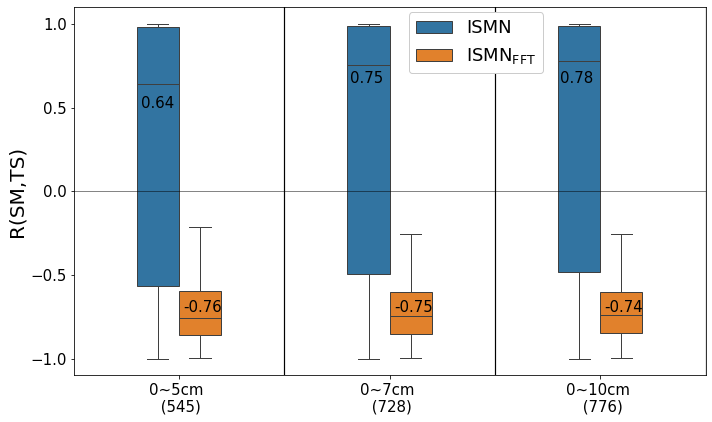

In [227]:
# Fig. S5
fig = plt.figure(figsize=(10,6))
fig.set_facecolor('white')
ax=sns.boxplot(data=df_long, x='depth', y='R', hue='type', dodge=True, width=0.4, showfliers=False)
plt.text(-.18,.5, round(ori_med_05,2),fontsize=15)
plt.text(.02,-.72, round(adj_med_05,2),fontsize=15)

plt.text(.81,.65, round(ori_med_07,2),fontsize=15)
plt.text(1.02,-.72, round(adj_med_07,2),fontsize=15)

plt.text(1.81,.65, round(ori_med_010,2),fontsize=15)
plt.text(2.02,-.72, round(adj_med_010,2),fontsize=15)

for x in [0.5, 1.5, 2.5]:
    ax.axvline(x=x, color='k', linestyle='-', linewidth=1.2)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles,['ISMN', r'ISMN$_{\text{FFT}}$'],fontsize=18,loc=[.53,.82],facecolor='white',framealpha=1)

plt.axhline(0, color='k', lw=0.8, alpha=0.6)
plt.ylabel('R(SM,TS)',fontsize=20)
plt.yticks([-1.0,-0.5,0,0.5,1],fontsize=15)
plt.xticks([0,1,2],[f'0~5cm \n (545)', f'0~7cm \n ({len(df_07)})', f'0~10cm \n ({len(df_010)})'], fontsize=15)
plt.xlabel('',fontsize=20)
plt.tight_layout()
plt.show()

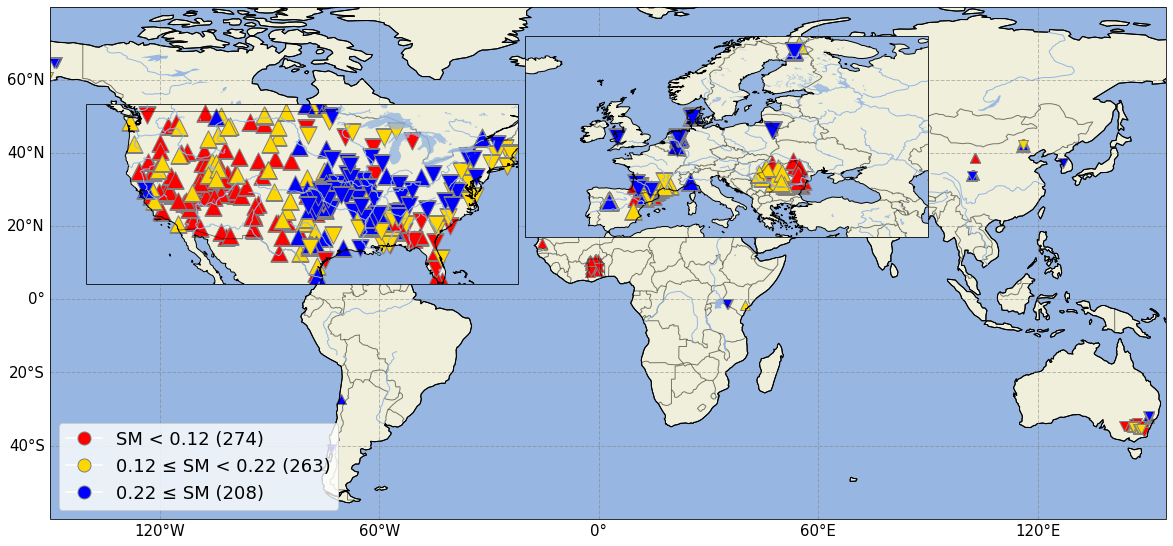

In [698]:
# Fig. S6
fig ,ax= plt.subplots(figsize=(20, 20), subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_facecolor('white')

R_p1 = np.array([value > 0 for value in sm1_ISMN])
R_n1 = np.array([value < 0 for value in sm1_ISMN])
R_p2 = np.array([value > 0 for value in sm2_ISMN])
R_n2 = np.array([value < 0 for value in sm2_ISMN])
R_p3 = np.array([value > 0 for value in sm3_ISMN])
R_n3 = np.array([value < 0 for value in sm3_ISMN])

plt.scatter(sm1_lon[R_p1], sm1_lat[R_p1],transform=cartopy.crs.PlateCarree(), s=100, color='red',edgecolor='gray', marker='^',)
plt.scatter(sm2_lon[R_p2], sm2_lat[R_p2],transform=cartopy.crs.PlateCarree(),s=100,color='gold',edgecolor='gray', marker='^')
plt.scatter(sm3_lon[R_p3], sm3_lat[R_p3],transform=cartopy.crs.PlateCarree(),s=100,color='blue',edgecolor='gray', marker='^')

plt.scatter(sm1_lon[R_n1], sm1_lat[R_n1],transform=cartopy.crs.PlateCarree(), s=100, color='red',edgecolor='gray', marker='v')
plt.scatter(sm2_lon[R_n2], sm2_lat[R_n2],transform=cartopy.crs.PlateCarree(),s=100,color='gold',edgecolor='gray', marker='v')
plt.scatter(sm3_lon[R_n3], sm3_lat[R_n3],transform=cartopy.crs.PlateCarree(),s=100,color='blue',edgecolor='gray', marker='v')

ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=.5)
ax.add_feature(cfeature.LAKES, alpha=0.95)
ax.add_feature(cfeature.RIVERS)
ax.set_extent([-150, 160, -60, 80], crs=ccrs.PlateCarree())
ax.set_xlim(-150, 155)
ax.set_ylim(-60, 80)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabel_style = {'size': 15}
gl.ylabel_style = {'size': 15}

custom_legend = [
    Line2D([0], [0], marker='o', color='w', label=fr'SM < 0.12 ({len_sm1})',
           markerfacecolor='red', markersize=13, markeredgecolor='gray'),
    Line2D([0], [0], marker='o', color='w', label=fr'0.12 ≤ SM < 0.22 ({len_sm2})',
           markerfacecolor='gold', markersize=13, markeredgecolor='gray'),
    Line2D([0], [0], marker='o', color='w', label=fr'0.22 ≤ SM ({len_sm3})',
           markerfacecolor='blue', markersize=13, markeredgecolor='gray')]
plt.legend(handles=custom_legend, loc='lower left', fontsize=18)

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'CONUS'
ax_inset = fig.add_axes([0.15, 0.40, 0.3, 0.3], projection=ccrs.PlateCarree())
ax_inset.set_extent([-130, -70, 25, 50], crs=ccrs.PlateCarree())  # CONUS 지역

ax_inset.coastlines()
ax_inset.add_feature(cfeature.LAND)
ax_inset.add_feature(cfeature.OCEAN)
ax_inset.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset.add_feature(cfeature.RIVERS)

ax_inset.scatter(sm1_lon[R_p1], sm1_lat[R_p1],transform=cartopy.crs.PlateCarree(), s=300, color='red',edgecolor='gray', marker='^',)
ax_inset.scatter(sm2_lon[R_p2], sm2_lat[R_p2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='^')
ax_inset.scatter(sm3_lon[R_p3], sm3_lat[R_p3],transform=cartopy.crs.PlateCarree(),s=300,color='blue',edgecolor='gray', marker='^')

ax_inset.scatter(sm1_lon[R_n1], sm1_lat[R_n1],transform=cartopy.crs.PlateCarree(), s=300, color='red',edgecolor='gray', marker='v')
ax_inset.scatter(sm2_lon[R_n2], sm2_lat[R_n2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='v')
ax_inset.scatter(sm3_lon[R_n3], sm3_lat[R_n3],transform=cartopy.crs.PlateCarree(),s=300,color='blue',edgecolor='gray', marker='v')

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
'EU'
ax_inset2 = fig.add_axes([0.455, 0.5, 0.28, 0.18], projection=ccrs.PlateCarree())
ax_inset2.set_extent([-20, 50, 35, 70], crs=ccrs.PlateCarree())  # 유럽 지역 범위 설정

ax_inset2.coastlines()
ax_inset2.add_feature(cfeature.LAND)
ax_inset2.add_feature(cfeature.OCEAN)
ax_inset2.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset2.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset2.add_feature(cfeature.RIVERS)

ax_inset2.scatter(sm1_lon[R_p1], sm1_lat[R_p1],transform=cartopy.crs.PlateCarree(), s=300, color='red',edgecolor='gray', marker='^',)
ax_inset2.scatter(sm2_lon[R_p2], sm2_lat[R_p2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='^')
ax_inset2.scatter(sm3_lon[R_p3], sm3_lat[R_p3],transform=cartopy.crs.PlateCarree(),s=300,color='blue',edgecolor='gray', marker='^')

ax_inset2.scatter(sm1_lon[R_n1], sm1_lat[R_n1],transform=cartopy.crs.PlateCarree(), s=300, color='red',edgecolor='gray', marker='v')
ax_inset2.scatter(sm2_lon[R_n2], sm2_lat[R_n2],transform=cartopy.crs.PlateCarree(),s=300,color='gold',edgecolor='gray', marker='v')
ax_inset2.scatter(sm3_lon[R_n3], sm3_lat[R_n3],transform=cartopy.crs.PlateCarree(),s=300,color='blue',edgecolor='gray', marker='v')

'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
plt.show()

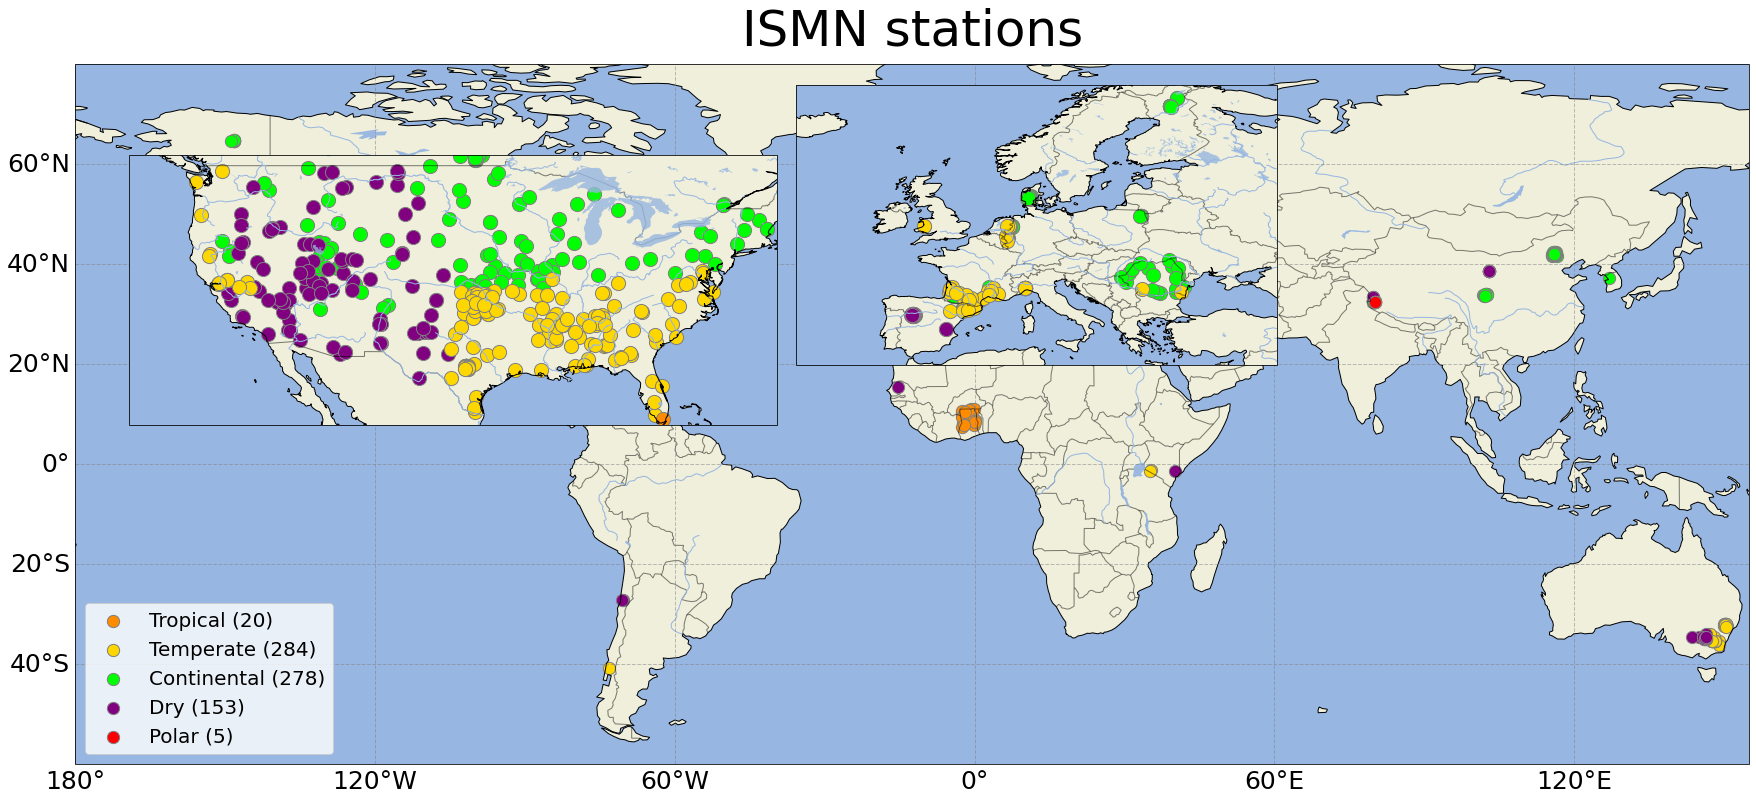

In [1402]:
# Fig. S7
fig = plt.figure(figsize=(30, 30))
fig.set_facecolor('white')

ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax.set_extent([-180, 155, -60, 80], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=.5)
ax.add_feature(cfeature.LAKES, alpha=0.95)
ax.add_feature(cfeature.RIVERS)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 25}
gl.ylabel_style = {'size': 25}

ax.scatter(ISMN_Tro['lon'], ISMN_Tro['lat'], transform=cartopy.crs.PlateCarree(),s=150,color='darkorange',edgecolor='gray',label='Tropical ({})'.format(len(ISMN_Tro)))
ax.scatter(ISMN_Tem['lon'], ISMN_Tem['lat'], transform=cartopy.crs.PlateCarree(),s=150,color='gold',edgecolor='gray',label='Temperate ({})'.format(len(ISMN_Tem)))
ax.scatter(ISMN_Con['lon'], ISMN_Con['lat'], transform=cartopy.crs.PlateCarree(), s=150, color='lime',edgecolor='gray', label='Continental ({})'.format(len(ISMN_Con)))
ax.scatter(ISMN_Dry['lon'], ISMN_Dry['lat'], transform=cartopy.crs.PlateCarree(),s=150,color='purple',edgecolor='gray',label='Dry ({})'.format(len(ISMN_Dry)))
ax.scatter(ISMN_Pol['lon'], ISMN_Pol['lat'], transform=cartopy.crs.PlateCarree(),s=150,color='red',edgecolor='gray',label='Polar ({})'.format(len(ISMN_Pol)))

ax.set_title('ISMN stations',fontsize=50,pad=20)
ax.legend(loc='lower left',fontsize=20)

# CONUS
ax_inset = fig.add_axes([0.15, 0.41, 0.3, 0.3], projection=ccrs.PlateCarree())
ax_inset.set_extent([-130, -70, 25, 50], crs=ccrs.PlateCarree())
ax_inset.coastlines()
ax_inset.add_feature(cfeature.LAND)
ax_inset.add_feature(cfeature.OCEAN)
ax_inset.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset.add_feature(cfeature.RIVERS)

ax_inset.scatter(ISMN_Con['lon'], ISMN_Con['lat'], transform=cartopy.crs.PlateCarree(), s=200, color='lime',edgecolor='gray', label='Continental ({})'.format(len(ISMN_Con)))
ax_inset.scatter(ISMN_Dry['lon'], ISMN_Dry['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='purple',edgecolor='gray',label='Dry ({})'.format(len(ISMN_Dry)))
ax_inset.scatter(ISMN_Pol['lon'], ISMN_Pol['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='red',edgecolor='gray',label='Polar ({})'.format(len(ISMN_Pol)))
ax_inset.scatter(ISMN_Tem['lon'], ISMN_Tem['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='gold',edgecolor='gray',label='Temperate ({})'.format(len(ISMN_Tem)))
ax_inset.scatter(ISMN_Tro['lon'], ISMN_Tro['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='darkorange',edgecolor='gray',label='Tropical ({})'.format(len(ISMN_Tro)))

# EU
ax_inset2 = fig.add_axes([0.455, 0.525, 0.23, 0.13], projection=ccrs.PlateCarree())
ax_inset2.set_extent([-20, 40, 35, 70], crs=ccrs.PlateCarree()) 
ax_inset2.coastlines()
ax_inset2.add_feature(cfeature.LAND)
ax_inset2.add_feature(cfeature.OCEAN)
ax_inset2.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.5)
ax_inset2.add_feature(cfeature.LAKES, alpha=0.8)
ax_inset2.add_feature(cfeature.RIVERS)

ax_inset2.scatter(ISMN_Con['lon'], ISMN_Con['lat'], transform=cartopy.crs.PlateCarree(), s=200, color='lime',edgecolor='gray', label='Continental ({})'.format(len(ISMN_Con)))
ax_inset2.scatter(ISMN_Dry['lon'], ISMN_Dry['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='purple',edgecolor='gray',label='Dry ({})'.format(len(ISMN_Dry)))
ax_inset2.scatter(ISMN_Pol['lon'], ISMN_Pol['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='red',edgecolor='gray',label='Polar ({})'.format(len(ISMN_Pol)))
ax_inset2.scatter(ISMN_Tem['lon'], ISMN_Tem['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='gold',edgecolor='gray',label='Temperate ({})'.format(len(ISMN_Tem)))
ax_inset2.scatter(ISMN_Tro['lon'], ISMN_Tro['lat'], transform=cartopy.crs.PlateCarree(),s=200,color='darkorange',edgecolor='gray',label='Tropical ({})'.format(len(ISMN_Tro)))

plt.show()

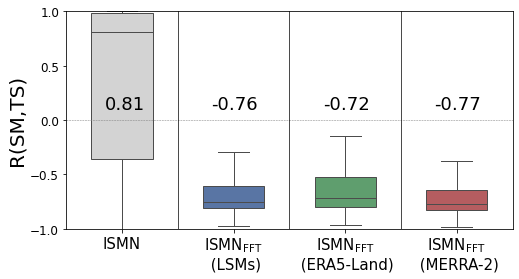

In [234]:
# Fig. S9
palette = ['lightgray', '#4C72B0', '#55A868', '#C44E52']

fig= plt.figure(figsize=(8,4))
fig.set_facecolor('white')
ax=sns.boxplot(data=df_7_concat, x='data', y='R', showfliers=False, palette=palette, width=0.55)
plt.ylabel('R(SM,TS)',fontsize=20)
plt.xlabel('')
ax.set_xticklabels(['ISMN','$\mathrm{ISMN_{FFT}}$ \n (LSMs)','$\mathrm{ISMN_{FFT}}$ \n (ERA5-Land)','$\mathrm{ISMN_{FFT}}$ \n (MERRA-2)'], fontsize=15)
plt.ylim(-1,1)
plt.yticks([-1,-.5,0,.5,1],fontsize=12)
plt.text(-.15,.1,round(med_ISMN,2),fontsize=18)
plt.text(.8,.1,round(med_adj_all,2),fontsize=18)
plt.text(1.8,.1,round(med_adj_E,2),fontsize=18)
plt.text(2.8,.1,round(med_adj_M,2),fontsize=18)
plt.axhline(0,linewidth=.5, linestyle='--', c='gray')
plt.axvline(.5,linewidth=.7, linestyle='-', c='k')
plt.axvline(1.5,linewidth=.7, linestyle='-', c='k')
plt.axvline(2.5,linewidth=.7, linestyle='-', c='k')
plt.show()

## data

In [1052]:
ERA_v,MERRA_v=(0.5, 0.5)
lat=[]
lon=[]
ISMN_cor_ano=[]
ISMN_cor_adj=[]
max_ts=[]
min_ts=[]
range_ts=[]
merge_list=[]
hourly_list=[]
bn_lat=[]
bn_lon=[]
bn_ISMN_cor_ano=[]
bn_ISMN_cor_adj=[]
bn_max_ts=[]
bn_min_ts=[]
bn_range_ts=[]
bn_merge_list=[]
bn_hourly_list=[]
before_noon=[]
error=[]
low_len=[]
idx=[]
bn_idx=[]
for i in range(len(ISMN_sm)):
    print(i,end='\r')
    try:
        ISMN=pd.read_csv(ISMN_sm[i],usecols={'date_time','soil_moisture','flag','anomaly','rm'},index_col='date_time',parse_dates=['date_time'])
        ERA=pd.read_csv(ERA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
        MERRA=pd.read_csv(MERRA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
        ts_ISMN=pd.read_csv(ISMN_ts[i],usecols={'date_time','soil_temperature','flag','anomaly'},index_col='date_time',parse_dates=['date_time'])
        ISMN2=pd.read_csv(ISMN_sm[i])
        
        ISMN=ISMN[ISMN['flag']=='G']
        ts_ISMN=ts_ISMN[ts_ISMN['flag']=='G']
        ISMN=ISMN[['soil_moisture','anomaly','rm']]
        ts_ISMN=ts_ISMN[['soil_temperature','anomaly']]
        
        ISMN.rename(columns={'soil_moisture':'ISMN sm','anomaly':'ISMN sm ano','rm':'ISMN rm'},inplace=True)
        ERA.rename(columns={'sm':'ERA sm','sm ano':'ERA sm ano','ts':'ERA ts','ts ano':'ERA ts ano'},inplace=True)
        MERRA.rename(columns={'sm':'MERRA sm','sm ano':'MERRA sm ano','ts':'MERRA ts','ts ano':'MERRA ts ano'},inplace=True)
        ts_ISMN.rename(columns={'soil_temperature':'ISMN ts','anomaly':'ISMN ts ano'},inplace=True)
        
        merged = ISMN.merge(ERA, left_index=True, right_index=True, how='inner')
        merged = merged.merge(MERRA, left_index=True, right_index=True, how='inner')
        merged = merged.merge(ts_ISMN, left_index=True, right_index=True, how='inner')
        merged = merged.dropna()

        if len(merged) > 2200:
            'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
            'anomaly'
            fft_ISMN_ano=np.fft.fft(merged['ISMN sm ano'])
            ps_ISMN_ano=np.abs(fft_ISMN_ano)
            freq_ISMN_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ISMN_ano))
            
            fft_ERA_ano=np.fft.fft(merged['ERA sm ano'])
            ps_ERA_ano=np.abs(fft_ERA_ano)
            freq_ERA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ERA_ano))
            
            fft_MERRA_ano=np.fft.fft(merged['MERRA sm ano'])
            ps_MERRA_ano=np.abs(fft_MERRA_ano)
            freq_MERRA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_MERRA_ano))
            
            freq_24=int(len(freq_ISMN_ano)/24)
            freq_36=int(len(freq_ISMN_ano)/36)
            freq_12=int(len(freq_ISMN_ano)/12)
            
            df_ano=pd.DataFrame()
            df_ano['fft_ISMN_r']=fft_ISMN_ano.real
            df_ano['fft_ERA_r']=fft_ERA_ano.real
            df_ano['fft_MERRA_r']=fft_MERRA_ano.real
            df_ano['fft_m_r']=((ERA_v*df_ano['fft_ERA_r'])+(MERRA_v*df_ano['fft_MERRA_r']))
            df_ano['fft_ISMN_i']=fft_ISMN_ano.imag
            df_ano['fft_ERA_i']=fft_ERA_ano.imag
            df_ano['fft_MERRA_i']=fft_MERRA_ano.imag
            df_ano['fft_m_i']=((ERA_v*df_ano['fft_ERA_i'])+(MERRA_v*df_ano['fft_MERRA_i']))
            df_ano['ps_ISMN']=ps_ISMN_ano
            df_ano['ps_ERA']=ps_ERA_ano
            df_ano['ps_MERRA']=ps_MERRA_ano
            df_ano['ps_m']=((ERA_v*df_ano['ps_ERA'])+(MERRA_v*df_ano['ps_MERRA']))
            
            mv_ano=df_ano.rolling(window=24,center=True).mean()
            
            sf_ano_E=mv_ano['ps_ISMN']/mv_ano['ps_ERA']
            sf_ano_M=mv_ano['ps_ISMN']/mv_ano['ps_MERRA']
            sf_ano_all=mv_ano['ps_ISMN']/mv_ano['ps_m']
            
            fft_ano_r_E=sf_ano_E*df_ano['fft_ERA_r']
            fft_ano_i_E=sf_ano_E*df_ano['fft_ERA_i']
            fft_ano_r_M=sf_ano_M*df_ano['fft_MERRA_r']
            fft_ano_i_M=sf_ano_M*df_ano['fft_MERRA_i']
            fft_ano_r_all=sf_ano_all*df_ano['fft_m_r']
            fft_ano_i_all=sf_ano_all*df_ano['fft_m_i']
            
            fft_ano_resc_E=fft_ano_r_E+fft_ano_i_E*1j
            fft_ano_resc_M=fft_ano_r_M+fft_ano_i_M*1j
            fft_ano_resc_all=fft_ano_r_all+fft_ano_i_all*1j
            
            fft_ISMN_adj_ano_E=fft_ISMN_ano.copy()
            fft_ISMN_adj_ano_M=fft_ISMN_ano.copy()
            fft_ISMN_adj_ano_all=fft_ISMN_ano.copy()
            
            fft_ISMN_adj_ano_E[freq_36:freq_12]=fft_ano_resc_E[freq_36:freq_12]
            fft_ISMN_adj_ano_E[-freq_12:-freq_36]=fft_ano_resc_E[-freq_12:-freq_36]
            fft_ISMN_adj_ano_M[freq_36:freq_12]=fft_ano_resc_M[freq_36:freq_12]
            fft_ISMN_adj_ano_M[-freq_12:-freq_36]=fft_ano_resc_M[-freq_12:-freq_36]
            fft_ISMN_adj_ano_all[freq_36:freq_12]=fft_ano_resc_all[freq_36:freq_12]
            fft_ISMN_adj_ano_all[-freq_12:-freq_36]=fft_ano_resc_all[-freq_12:-freq_36]
            
            ps_ano_adj_E=np.abs(fft_ISMN_adj_ano_E)
            ps_ano_adj_M=np.abs(fft_ISMN_adj_ano_M)
            ps_ano_adj_all=np.abs(fft_ISMN_adj_ano_all)
            
            ifft_ISMN_ano_E=np.fft.ifft(fft_ISMN_adj_ano_E)
            ifft_ISMN_ano_real_E=ifft_ISMN_ano_E.real
            ifft_ISMN_ano_M=np.fft.ifft(fft_ISMN_adj_ano_M)
            ifft_ISMN_ano_real_M=ifft_ISMN_ano_M.real
            ifft_ISMN_ano_all=np.fft.ifft(fft_ISMN_adj_ano_all)
            ifft_ISMN_ano_real_all=ifft_ISMN_ano_all.real
            
            merged['ano_adj_E']=ifft_ISMN_ano_real_E
            merged['ano_adj_M']=ifft_ISMN_ano_real_M
            merged['ano_adj_all']=ifft_ISMN_ano_real_all
            
            merged_copy=merged.copy()
            merged_copy['date']=merged_copy.index.date
            merged_copy['hour']=merged_copy.index.hour
            merged_copy=merged_copy.groupby('date', group_keys=False).apply(adjust_night)
            filter_date=merged_copy.loc[merged_copy['night_adj'] < 0, 'date'].unique()
            merged_copy['night_adj2']=merged_copy['night_adj']
        
            for j in filter_date:
                filter_start=merged_copy[merged_copy['date'] == j][['night_adj']].copy()
                night_mean=np.mean(filter_start['night_adj'])
                filter_start['step1']=filter_start['night_adj']-night_mean
                filter_min=np.min(filter_start['step1'])
                if night_mean > 0 : 
                    if abs(filter_min) < 1:
                        filter_start['step2']=filter_start['step1']*abs(filter_min)
                        filter_start['step3']=filter_start['step2']+night_mean
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
                    elif abs(filter_min) > 1:
                        filter_start['step2']=filter_start['step1']/abs(filter_min)
                        filter_start['step3']=filter_start['step2']+night_mean
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
                elif night_mean < 0 :
                    if abs(filter_min) < 1:
                        filter_start['step2']=filter_start['step1']*abs(filter_min)
                        filter_start['step3']=filter_start['step2']+abs(np.min(filter_start['step2']))
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
                    elif abs(filter_min) > 1:
                        filter_start['step2']=filter_start['step1']/abs(filter_min)
                        filter_start['step3']=filter_start['step2']+abs(np.min(filter_start['step2']))
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']

            merged_copy=merged_copy.drop(columns=['date','hour'])
            hourly=merged_copy.groupby(merged_copy.index.hour).mean()            
            
            if (np.argmax(hourly['ISMN sm ano']) >= 12):
                lat.append(ISMN2.latitude[0])
                lon.append(ISMN2.longitude[0])
                ISMN_cor_ano.append(np.corrcoef(hourly['ISMN sm ano'],hourly['ISMN ts ano'])[0,1])       # ISMN ano R(sm,ts)
                ISMN_cor_adj.append(np.corrcoef(hourly['night_adj'],hourly['ISMN ts ano'])[0,1])             # ISMN R(sm_adj,ts)
                max_ts.append(np.max(hourly['ISMN ts']))
                min_ts.append(np.min(hourly['ISMN ts']))
                range_ts.append(np.max(hourly['ISMN ts'])-np.min(hourly['ISMN ts']))
                merge_list.append(merged_copy)
                hourly_list.append(hourly)
                idx.append(i)
            else : 
                bn_lat.append(ISMN2.latitude[0])
                bn_lon.append(ISMN2.longitude[0])
                bn_ISMN_cor_ano.append(np.corrcoef(hourly['ISMN sm ano'],hourly['ISMN ts ano'])[0,1])       # ISMN ano R(sm,ts)
                bn_ISMN_cor_adj.append(np.corrcoef(hourly['night_adj'],hourly['ISMN ts ano'])[0,1])             # ISMN R(sm_adj,ts)
                bn_max_ts.append(np.max(hourly['ISMN ts']))
                bn_min_ts.append(np.min(hourly['ISMN ts']))
                bn_range_ts.append(np.max(hourly['ISMN ts'])-np.min(hourly['ISMN ts']))
                bn_merge_list.append(merged_copy)
                bn_hourly_list.append(hourly)
                bn_idx.append(i)
            del night,hourly
        else:
            low_len.append(i)
    except Exception as e:
        error.append((i,e))

In [1119]:
ERA_v,MERRA_v=(0.5, 0.5)
lat=[]
lon=[]
ISMN_cor_ano=[]
ISMN_cor_adj=[]
ERA_cor_ano=[]
MERA_cor_ano=[]
ISMN_climate=[]
merge_list=[]
hourly_list=[]
bn_lat=[]
bn_lon=[]
bn_ISMN_cor_ano=[]
bn_ISMN_cor_adj=[]
bn_ERA_cor_ano=[]
bn_MERA_cor_ano=[]
bn_ISMN_climate=[]
bn_merge_list=[]
bn_hourly_list=[]
before_noon=[]
error=[]
low_len=[]
idx=[]
bn_idx=[]
for i in range(len(ISMN_sm)):
    print(i,end='\r')
    try:
        ISMN=pd.read_csv(ISMN_sm[i],usecols={'date_time','soil_moisture','flag','anomaly','rm'},index_col='date_time',parse_dates=['date_time'])
        ERA=pd.read_csv(ERA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
        MERRA=pd.read_csv(MERRA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
        ts_ISMN=pd.read_csv(ISMN_ts[i],usecols={'date_time','soil_temperature','flag','anomaly'},index_col='date_time',parse_dates=['date_time'])
        ISMN2=pd.read_csv(ISMN_sm[i])
        
        ISMN=ISMN[ISMN['flag']=='G']
        ts_ISMN=ts_ISMN[ts_ISMN['flag']=='G']
        ISMN=ISMN[['soil_moisture','anomaly','rm']]
        ts_ISMN=ts_ISMN[['soil_temperature','anomaly']]
        
        ISMN.rename(columns={'soil_moisture':'ISMN sm','anomaly':'ISMN sm ano','rm':'ISMN rm'},inplace=True)
        ERA.rename(columns={'sm':'ERA sm','sm ano':'ERA sm ano','ts':'ERA ts','ts ano':'ERA ts ano'},inplace=True)
        MERRA.rename(columns={'sm':'MERRA sm','sm ano':'MERRA sm ano','ts':'MERRA ts','ts ano':'MERRA ts ano'},inplace=True)
        ts_ISMN.rename(columns={'soil_temperature':'ISMN ts','anomaly':'ISMN ts ano'},inplace=True)
        
        merged = ISMN.merge(ERA, left_index=True, right_index=True, how='inner')
        merged = merged.merge(MERRA, left_index=True, right_index=True, how='inner')
        merged = merged.merge(ts_ISMN, left_index=True, right_index=True, how='inner')
        merged = merged.dropna()

        if len(merged) > 2200:
            'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
            'anomaly'
            fft_ISMN_ano=np.fft.fft(merged['ISMN sm ano'])
            ps_ISMN_ano=np.abs(fft_ISMN_ano)
            freq_ISMN_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ISMN_ano))
            
            fft_ERA_ano=np.fft.fft(merged['ERA sm ano'])
            ps_ERA_ano=np.abs(fft_ERA_ano)
            freq_ERA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ERA_ano))
            
            fft_MERRA_ano=np.fft.fft(merged['MERRA sm ano'])
            ps_MERRA_ano=np.abs(fft_MERRA_ano)
            freq_MERRA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_MERRA_ano))
            
            freq_24=int(len(freq_ISMN_ano)/24)
            freq_36=int(len(freq_ISMN_ano)/36)
            freq_12=int(len(freq_ISMN_ano)/12)
            
            df_ano=pd.DataFrame()
            df_ano['fft_ISMN_r']=fft_ISMN_ano.real
            df_ano['fft_ERA_r']=fft_ERA_ano.real
            df_ano['fft_MERRA_r']=fft_MERRA_ano.real
            df_ano['fft_m_r']=((ERA_v*df_ano['fft_ERA_r'])+(MERRA_v*df_ano['fft_MERRA_r']))
            df_ano['fft_ISMN_i']=fft_ISMN_ano.imag
            df_ano['fft_ERA_i']=fft_ERA_ano.imag
            df_ano['fft_MERRA_i']=fft_MERRA_ano.imag
            df_ano['fft_m_i']=((ERA_v*df_ano['fft_ERA_i'])+(MERRA_v*df_ano['fft_MERRA_i']))
            df_ano['ps_ISMN']=ps_ISMN_ano
            df_ano['ps_ERA']=ps_ERA_ano
            df_ano['ps_MERRA']=ps_MERRA_ano
            df_ano['ps_m']=((ERA_v*df_ano['ps_ERA'])+(MERRA_v*df_ano['ps_MERRA']))
            
            mv_ano=df_ano.rolling(window=24,center=True).mean()
            
            sf_ano_E=mv_ano['ps_ISMN']/mv_ano['ps_ERA']
            sf_ano_M=mv_ano['ps_ISMN']/mv_ano['ps_MERRA']
            sf_ano_all=mv_ano['ps_ISMN']/mv_ano['ps_m']
            
            fft_ano_r_E=sf_ano_E*df_ano['fft_ERA_r']
            fft_ano_i_E=sf_ano_E*df_ano['fft_ERA_i']
            fft_ano_r_M=sf_ano_M*df_ano['fft_MERRA_r']
            fft_ano_i_M=sf_ano_M*df_ano['fft_MERRA_i']
            fft_ano_r_all=sf_ano_all*df_ano['fft_m_r']
            fft_ano_i_all=sf_ano_all*df_ano['fft_m_i']
            
            fft_ano_resc_E=fft_ano_r_E+fft_ano_i_E*1j
            fft_ano_resc_M=fft_ano_r_M+fft_ano_i_M*1j
            fft_ano_resc_all=fft_ano_r_all+fft_ano_i_all*1j
            
            fft_ISMN_adj_ano_E=fft_ISMN_ano.copy()
            fft_ISMN_adj_ano_M=fft_ISMN_ano.copy()
            fft_ISMN_adj_ano_all=fft_ISMN_ano.copy()
            
            fft_ISMN_adj_ano_E[freq_36:freq_12]=fft_ano_resc_E[freq_36:freq_12]
            fft_ISMN_adj_ano_E[-freq_12:-freq_36]=fft_ano_resc_E[-freq_12:-freq_36]
            fft_ISMN_adj_ano_M[freq_36:freq_12]=fft_ano_resc_M[freq_36:freq_12]
            fft_ISMN_adj_ano_M[-freq_12:-freq_36]=fft_ano_resc_M[-freq_12:-freq_36]
            fft_ISMN_adj_ano_all[freq_36:freq_12]=fft_ano_resc_all[freq_36:freq_12]
            fft_ISMN_adj_ano_all[-freq_12:-freq_36]=fft_ano_resc_all[-freq_12:-freq_36]
            
            ps_ano_adj_E=np.abs(fft_ISMN_adj_ano_E)
            ps_ano_adj_M=np.abs(fft_ISMN_adj_ano_M)
            ps_ano_adj_all=np.abs(fft_ISMN_adj_ano_all)
            
            ifft_ISMN_ano_E=np.fft.ifft(fft_ISMN_adj_ano_E)
            ifft_ISMN_ano_real_E=ifft_ISMN_ano_E.real
            ifft_ISMN_ano_M=np.fft.ifft(fft_ISMN_adj_ano_M)
            ifft_ISMN_ano_real_M=ifft_ISMN_ano_M.real
            ifft_ISMN_ano_all=np.fft.ifft(fft_ISMN_adj_ano_all)
            ifft_ISMN_ano_real_all=ifft_ISMN_ano_all.real
            
            merged['ano_adj_E']=ifft_ISMN_ano_real_E
            merged['ano_adj_M']=ifft_ISMN_ano_real_M
            merged['ano_adj_all']=ifft_ISMN_ano_real_all
            
            merged_copy=merged.copy()
            merged_copy['date']=merged_copy.index.date
            merged_copy['hour']=merged_copy.index.hour
            merged_copy=merged_copy.groupby('date', group_keys=False).apply(adjust_night)
            filter_date=merged_copy.loc[merged_copy['night_adj'] < 0, 'date'].unique()
            merged_copy['night_adj2']=merged_copy['night_adj']
        
            for j in filter_date:
                filter_start=merged_copy[merged_copy['date'] == j][['night_adj']].copy()
                night_mean=np.mean(filter_start['night_adj'])
                filter_start['step1']=filter_start['night_adj']-night_mean
                filter_min=np.min(filter_start['step1'])
                if night_mean > 0 : 
                    if abs(filter_min) < 1:
                        filter_start['step2']=filter_start['step1']*abs(filter_min)
                        filter_start['step3']=filter_start['step2']+night_mean
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
                    elif abs(filter_min) > 1:
                        filter_start['step2']=filter_start['step1']/abs(filter_min)
                        filter_start['step3']=filter_start['step2']+night_mean
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
                elif night_mean < 0 :
                    if abs(filter_min) < 1:
                        filter_start['step2']=filter_start['step1']*abs(filter_min)
                        filter_start['step3']=filter_start['step2']+abs(np.min(filter_start['step2']))
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']
                    elif abs(filter_min) > 1:
                        filter_start['step2']=filter_start['step1']/abs(filter_min)
                        filter_start['step3']=filter_start['step2']+abs(np.min(filter_start['step2']))
                        merged_copy.loc[filter_start.index, 'night_adj2'] = filter_start['step3']

            merged_copy=merged_copy.drop(columns=['date','hour'])
            hourly=merged_copy.groupby(merged_copy.index.hour).mean()            
            
            if (np.argmax(hourly['ISMN sm ano']) >= 12):
                lat.append(ISMN2.latitude[0])
                lon.append(ISMN2.longitude[0])
                ISMN_cor_ano.append(np.corrcoef(hourly['ISMN sm ano'],hourly['ISMN ts ano'])[0,1])       # ISMN ano R(sm,ts)
                ISMN_cor_adj.append(np.corrcoef(hourly['night_adj'],hourly['ISMN ts ano'])[0,1])             # ISMN R(sm_adj,ts)
                ERA_cor_ano.append(np.corrcoef(hourly['ERA sm ano'],hourly['ERA ts ano'])[0,1])
                MERA_cor_ano.append(np.corrcoef(hourly['MERRA sm ano'],hourly['MERRA ts ano'])[0,1])
                ISMN_climate.append(ISMN2.climate[0])
                merge_list.append(merged_copy)
                hourly_list.append(hourly)
                idx.append(i)
            else : 
                bn_lat.append(ISMN2.latitude[0])
                bn_lon.append(ISMN2.longitude[0])
                bn_ISMN_cor_ano.append(np.corrcoef(hourly['ISMN sm ano'],hourly['ISMN ts ano'])[0,1])       # ISMN ano R(sm,ts)
                bn_ISMN_cor_adj.append(np.corrcoef(hourly['night_adj'],hourly['ISMN ts ano'])[0,1])             # ISMN R(sm_adj,ts)
                bn_ERA_cor_ano.append(np.corrcoef(hourly['ERA sm ano'],hourly['ERA ts ano'])[0,1])
                bn_MERA_cor_ano.append(np.corrcoef(hourly['MERRA sm ano'],hourly['MERRA ts ano'])[0,1])                
                bn_ISMN_climate.append(ISMN2.climate[0])
                bn_merge_list.append(merged_copy)
                bn_hourly_list.append(hourly)
                bn_idx.append(i)
            del night,hourly
        else:
            low_len.append(i)
    except Exception as e:
        error.append((i,e))

In [1119]:
ERA_v,MERRA_v=(0.5, 0.5)
lat=[]
lon=[]
ISMN_cor_ano=[]
merge_list=[]
hourly_list=[]
bn_lat=[]
bn_lon=[]
bn_ISMN_cor_ano=[]
bn_merge_list=[]
bn_hourly_list=[]
before_noon=[]
error=[]
low_len=[]
idx=[]
bn_idx=[]
for i in range(len(ISMN_sm)):
    print(i,end='\r')
    try:
        ISMN=pd.read_csv(ISMN_sm[i],usecols={'date_time','soil_moisture','flag','anomaly','rm'},index_col='date_time',parse_dates=['date_time'])
        ERA=pd.read_csv(ERA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
        MERRA=pd.read_csv(MERRA_data[i],usecols={'date_time','sm','sm ano','ts','ts ano'},index_col='date_time',parse_dates=['date_time'])
        ts_ISMN=pd.read_csv(ISMN_ts[i],usecols={'date_time','soil_temperature','flag','anomaly'},index_col='date_time',parse_dates=['date_time'])
        ISMN2=pd.read_csv(ISMN_sm[i])
        
        ISMN=ISMN[ISMN['flag']=='G']
        ts_ISMN=ts_ISMN[ts_ISMN['flag']=='G']
        ISMN=ISMN[['soil_moisture','anomaly','rm']]
        ts_ISMN=ts_ISMN[['soil_temperature','anomaly']]
        
        ISMN.rename(columns={'soil_moisture':'ISMN sm','anomaly':'ISMN sm ano','rm':'ISMN rm'},inplace=True)
        ERA.rename(columns={'sm':'ERA sm','sm ano':'ERA sm ano','ts':'ERA ts','ts ano':'ERA ts ano'},inplace=True)
        MERRA.rename(columns={'sm':'MERRA sm','sm ano':'MERRA sm ano','ts':'MERRA ts','ts ano':'MERRA ts ano'},inplace=True)
        ts_ISMN.rename(columns={'soil_temperature':'ISMN ts','anomaly':'ISMN ts ano'},inplace=True)
        
        merged = ISMN.merge(ERA, left_index=True, right_index=True, how='inner')
        merged = merged.merge(MERRA, left_index=True, right_index=True, how='inner')
        merged = merged.merge(ts_ISMN, left_index=True, right_index=True, how='inner')
        merged = merged.dropna()

        if len(merged) > 2200:
            'ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ'
            'anomaly'
            fft_ISMN_ano=np.fft.fft(merged['ISMN sm ano'])
            ps_ISMN_ano=np.abs(fft_ISMN_ano)
            freq_ISMN_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ISMN_ano))
            
            fft_ERA_ano=np.fft.fft(merged['ERA sm ano'])
            ps_ERA_ano=np.abs(fft_ERA_ano)
            freq_ERA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_ERA_ano))
            
            fft_MERRA_ano=np.fft.fft(merged['MERRA sm ano'])
            ps_MERRA_ano=np.abs(fft_MERRA_ano)
            freq_MERRA_ano=np.fft.fftfreq(len(merged),d=1.0/len(fft_MERRA_ano))
            
            freq_24=int(len(freq_ISMN_ano)/24)
            freq_36=int(len(freq_ISMN_ano)/36)
            freq_12=int(len(freq_ISMN_ano)/12)
            
            df_ano=pd.DataFrame()
            df_ano['fft_ISMN_r']=fft_ISMN_ano.real
            df_ano['fft_ERA_r']=fft_ERA_ano.real
            df_ano['fft_MERRA_r']=fft_MERRA_ano.real
            df_ano['fft_m_r']=((ERA_v*df_ano['fft_ERA_r'])+(MERRA_v*df_ano['fft_MERRA_r']))
            df_ano['fft_ISMN_i']=fft_ISMN_ano.imag
            df_ano['fft_ERA_i']=fft_ERA_ano.imag
            df_ano['fft_MERRA_i']=fft_MERRA_ano.imag
            df_ano['fft_m_i']=((ERA_v*df_ano['fft_ERA_i'])+(MERRA_v*df_ano['fft_MERRA_i']))
            df_ano['ps_ISMN']=ps_ISMN_ano
            df_ano['ps_ERA']=ps_ERA_ano
            df_ano['ps_MERRA']=ps_MERRA_ano
            df_ano['ps_m']=((ERA_v*df_ano['ps_ERA'])+(MERRA_v*df_ano['ps_MERRA']))
            
            mv_ano=df_ano.rolling(window=24,center=True).mean()
            
            sf_ano_E=mv_ano['ps_ISMN']/mv_ano['ps_ERA']
            sf_ano_M=mv_ano['ps_ISMN']/mv_ano['ps_MERRA']
            sf_ano_all=mv_ano['ps_ISMN']/mv_ano['ps_m']
            
            fft_ano_r_E=sf_ano_E*df_ano['fft_ERA_r']
            fft_ano_i_E=sf_ano_E*df_ano['fft_ERA_i']
            fft_ano_r_M=sf_ano_M*df_ano['fft_MERRA_r']
            fft_ano_i_M=sf_ano_M*df_ano['fft_MERRA_i']
            fft_ano_r_all=sf_ano_all*df_ano['fft_m_r']
            fft_ano_i_all=sf_ano_all*df_ano['fft_m_i']
            
            fft_ano_resc_E=fft_ano_r_E+fft_ano_i_E*1j
            fft_ano_resc_M=fft_ano_r_M+fft_ano_i_M*1j
            fft_ano_resc_all=fft_ano_r_all+fft_ano_i_all*1j
            
            fft_ISMN_adj_ano_E=fft_ISMN_ano.copy()
            fft_ISMN_adj_ano_M=fft_ISMN_ano.copy()
            fft_ISMN_adj_ano_all=fft_ISMN_ano.copy()
            
            fft_ISMN_adj_ano_E[freq_36:freq_12]=fft_ano_resc_E[freq_36:freq_12]
            fft_ISMN_adj_ano_E[-freq_12:-freq_36]=fft_ano_resc_E[-freq_12:-freq_36]
            fft_ISMN_adj_ano_M[freq_36:freq_12]=fft_ano_resc_M[freq_36:freq_12]
            fft_ISMN_adj_ano_M[-freq_12:-freq_36]=fft_ano_resc_M[-freq_12:-freq_36]
            fft_ISMN_adj_ano_all[freq_36:freq_12]=fft_ano_resc_all[freq_36:freq_12]
            fft_ISMN_adj_ano_all[-freq_12:-freq_36]=fft_ano_resc_all[-freq_12:-freq_36]
            
            ps_ano_adj_E=np.abs(fft_ISMN_adj_ano_E)
            ps_ano_adj_M=np.abs(fft_ISMN_adj_ano_M)
            ps_ano_adj_all=np.abs(fft_ISMN_adj_ano_all)
            
            ifft_ISMN_ano_E=np.fft.ifft(fft_ISMN_adj_ano_E)
            ifft_ISMN_ano_real_E=ifft_ISMN_ano_E.real
            ifft_ISMN_ano_M=np.fft.ifft(fft_ISMN_adj_ano_M)
            ifft_ISMN_ano_real_M=ifft_ISMN_ano_M.real
            ifft_ISMN_ano_all=np.fft.ifft(fft_ISMN_adj_ano_all)
            ifft_ISMN_ano_real_all=ifft_ISMN_ano_all.real
            
            merged['ano_adj_E']=ifft_ISMN_ano_real_E
            merged['ano_adj_M']=ifft_ISMN_ano_real_M
            merged['ano_adj_all']=ifft_ISMN_ano_real_all
            
            hourly=merged.groupby(merged.index.hour).mean()

            if (np.argmax(hourly['ISMN sm ano']) >= 12):
                lat.append(ISMN2.latitude[0])
                lon.append(ISMN2.longitude[0])
                ISMN_cor_ano.append(np.corrcoef(hourly['ISMN sm ano'],hourly['ISMN ts ano'])[0,1])       # ISMN ano R(sm,ts)
                merge_list.append(merged_copy)
                hourly_list.append(hourly)
                idx.append(i)
            else : 
                bn_lat.append(ISMN2.latitude[0])
                bn_lon.append(ISMN2.longitude[0])
                bn_ISMN_cor_ano.append(np.corrcoef(hourly['ISMN sm ano'],hourly['ISMN ts ano'])[0,1])       # ISMN ano R(sm,ts)
                bn_merge_list.append(merged_copy)
                bn_hourly_list.append(hourly)
                bn_idx.append(i)
            del night,hourly
        else:
            low_len.append(i)
    except Exception as e:
        error.append((i,e))